# About

This notebook will be for the text detection and segmentation of the notes. That is, not the conversion of handwriting to text, but the separation of handwriting into different lines/categories

**Vision**

What it does

- Utilize YoloV11n-seg (most recent smallest segmentation model that Ultralytics offers)
- Separates each line into a different segmentation
- Multiple categories for segmentation, corresponding to different stylings

I/O

- Pass in the raw scanned image of a page (maybe segmented into smaller portions already, cropped a little)
- Segments each line tightly, with a certain label
    - Could be something like 'header', 'main content', 'list point', 'image'
- Outputs segmentations, which are then individually converted to text and reassembled based on classes and location

Training Data

- Will (most likely) be using my Hands on Machine Learning notes to start, but may also do other class notes, or just some notes that seem like they have good formatting that I like
- Will have to manually segment pages, as well as translate them, whcih may take a little while

Possible Hurdles

- Numerical things that would be good in latex might be hard to do, could end up translating them but I'm not sure of the TrOCR model works that way (since it's trying to match visually as well)
- There might be a lot of training data needed in order to really tune this well, as well as a variety (different types of notebooks, pens, writing clarity, etc)
- It'll probably take a while to compute, will have to figure out what to do with that (maybe combine into one line? multiple lines in one request?)


# Imports

In [1]:
from ultralytics import YOLO
from ultralytics.data.split import autosplit
from ultralytics.utils.ops import xyxy2xywh, xywh2xyxy 
from pathlib import Path
import random
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt
from anytree import Node, RenderTree
import seaborn as sns
from sklearn.cluster import DBSCAN
from collections import namedtuple

# First Approach

We go line by line, putting bounding boxes around each line. We'll have five classes:

1. Header 
2. Text
3. Unordered Bullet
4. Ordered Bullet
5. Figure

This way, we're able to classify the different types of text. The idea for heirarchy is this:

- Have labelling for bounding boxes be very precise when it comes to alignment
- Use the left-edge of the bounding box to group different sections 
- Use the space between bounding boxes to separate paragraphs, figure out line breaks

## Tiny Test

Only three images labelled by tonight, but I want to see if thats even close to enough. I fell like it might be not too bad, since there's so many bounding boxes for each.

In [2]:
# Load the models
nano_model = YOLO('yolo11n-obb.pt')
small_model = YOLO('yolo11s-obb.pt')
medium_model = YOLO('yolo11m-obb.pt')

In [3]:
# Define function for training, validation
def train_model(model, yaml_path):
    result = model.train(
        data=yaml_path,
        epochs=10,
        imgsz=1024
    )

    return result.results_dict

In [4]:
model_results = []
yaml_path = r'datasets\dataset\tiny_data.yaml'

for model in [nano_model, small_model, medium_model]:
    results = train_model(model, yaml_path)
    model_results.append(results)

New https://pypi.org/project/ultralytics/8.3.186 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset\tiny_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train7, nbs=64, nms=False, ops

train: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\dataset\labels... 2 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2/2 [00:00<00:00, 103.59it/s]

train: New cache created: C:\Users\gjbur\Desktop\Code\note-transfer\development\dataset\labels.cache


val: Fast image access  (ping: 0.20.0 ms, read: 167.10.0 MB/s, size: 186.5 KB)


val: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\dataset\labels... 1 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1/1 [00:00<00:00, 61.50it/s]

...

      10/10      3.22G      4.492      3.821      4.788         60       1024: 100%|██████████| 1/1 [00:00<00:00,  1.63it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 11.07it/s]

                   all          1         31          0          0          0          0



10 epochs completed in 0.014 hours.
Optimizer stripped from c:\Users\gjbur\Desktop\Code\note-transfer\runs\obb\train9\weights\last.pt, 42.3MB
Optimizer stripped from c:\Users\gjbur\Desktop\Code\note-transfer\runs\obb\train9\weights\best.pt, 42.3MB

Validating c:\Users\gjbur\Desktop\Code\note-transfer\runs\obb\train9\weights\best.pt...
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
YOLO11m-obb summary (fused): 134 layers, 20,882,338 parameters, 0 gradients, 71.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 15.40it/s]


                   all          1         31          0          0          0          0
                Header          1          2          0          0          0          0
      Unordered Bullet          1          4          0          0          0          0
        Ordered Bullet          1         20          0          0          0          0
                  Text          1          5          0          0          0          0
Speed: 7.2ms preprocess, 46.2ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to c:\Users\gjbur\Desktop\Code\note-transfer\runs\obb\train9


In [5]:
model_results

[{'metrics/precision(B)': np.float64(0.0),
  'metrics/recall(B)': np.float64(0.0),
  'metrics/mAP50(B)': np.float64(0.0),
  'metrics/mAP50-95(B)': np.float64(0.0),
  'fitness': np.float64(0.0)},
 {'metrics/precision(B)': np.float64(0.0),
  'metrics/recall(B)': np.float64(0.0),
  'metrics/mAP50(B)': np.float64(0.0),
  'metrics/mAP50-95(B)': np.float64(0.0),
  'fitness': np.float64(0.0)},
 {'metrics/precision(B)': np.float64(0.0),
  'metrics/recall(B)': np.float64(0.0),
  'metrics/mAP50(B)': np.float64(0.0),
  'metrics/mAP50-95(B)': np.float64(0.0),
  'fitness': np.float64(0.0)}]

Yeah, no. We'll probably need to do **a lot** more labelling.

# Trying Small Dataset

Here, we'll see with my extrememly small 19 page dataset, if we can get anything out of this model (or even just the regular model). I'll keep iterating on this code until I get all 19 images, test on OBBs and regular bounding boxes. If nothing works, we may have to do some pre-segmentation to increase our data size.

In [2]:
# Load the models
nano_model = YOLO('yolo11n-obb.pt')
small_model = YOLO('yolo11s-obb.pt')
medium_model = YOLO('yolo11m-obb.pt')

In [3]:
# Define function for training, validation
def train_model(model, yaml_path):
    result = model.train(
        data=yaml_path,
        epochs=5,
    )

    return result.results_dict

In [4]:
model_results = []
yaml_path = r'datasets\dataset\small_data.yaml'

for model in [nano_model, small_model, medium_model]:
    results = train_model(model, yaml_path)
    model_results.append(results)

New https://pypi.org/project/ultralytics/8.3.176 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset\small_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train4, nbs=64, nms=False, ops

train: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\dataset\labels... 7 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7/7 [00:00<00:00, 2176.28it/s]

train: New cache created: C:\Users\gjbur\Desktop\Code\note-transfer\development\dataset\labels.cache


val: Fast image access  (ping: 0.30.0 ms, read: 256.136.3 MB/s, size: 212.8 KB)


val: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\dataset\labels... 3 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3/3 [00:00<00:00, 527.23it/s]

...

        5/5      9.17G      4.709      4.074      4.433        219       1024: 100%|██████████| 1/1 [00:12<00:00, 12.74s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  5.47it/s]

                   all          3         89          0          0          0          0



5 epochs completed in 0.027 hours.
Optimizer stripped from c:\Users\gjbur\Desktop\Code\note-transfer\runs\obb\train6\weights\last.pt, 42.4MB
Optimizer stripped from c:\Users\gjbur\Desktop\Code\note-transfer\runs\obb\train6\weights\best.pt, 42.4MB

Validating c:\Users\gjbur\Desktop\Code\note-transfer\runs\obb\train6\weights\best.pt...
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
YOLO11m-obb summary (fused): 134 layers, 20,882,338 parameters, 0 gradients, 71.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  3.75it/s]


                   all          3         89          0          0          0          0
                Header          3         15          0          0          0          0
      Unordered Bullet          3         23          0          0          0          0
                  Text          3         46          0          0          0          0
                Figure          1          5          0          0          0          0
Speed: 3.4ms preprocess, 75.6ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to c:\Users\gjbur\Desktop\Code\note-transfer\runs\obb\train6


I mean, I think it just won't work with this little data, we need to expand. Onto double the models, a little more labelling... two-step segmentation!

# Two-step Segmentation

With this we'll be labelling the general sections, and then segmenting everything in those sections.

First, we start with general section labelling. The layout here is:

- Each section will be defined by its right margin and space in between
- To start, we'll try using the categories still, defining each as a larger section instead of a line

It'll be useful to have the distinction between sections with the categories (Header, Text, Unordered Bullet, Ordered Bullet, Figure) as we may use that information for more precise classification per line later. But even if it's not used, we can just consolidate the labels and use the overall spatial detection on the document.

## Training, Testing

Have to finesse the data a little

In [19]:
import os
import re
from pathlib import Path

In [24]:
path = r'datasets\large-section-dataset\labels\train'
for file_name in os.listdir(path):
    file_path = Path(os.path.join(path, file_name))
    with open(file_path, 'r+') as f:
        content = f.read()
        replaced = re.sub('\n5 ', '\n0 ', content)
        replaced = '0' + replaced[1:]
        f.seek(0)
        f.write(replaced)
        f.truncate()


Now onto training

In [2]:
# Load the models
nano_model = YOLO('yolo11n-obb.pt')

# Define function for training, validation
def train_model(model, yaml_path):
    result = model.train(
        data=yaml_path,
        epochs=50,
        project='runs/obb'
    )

    return result.results_dict

model_results = []
yaml_path = r'datasets\large-section-dataset\data.yaml'

for model in [nano_model]:
    results = train_model(model, yaml_path)
    model_results.append(results)

New https://pypi.org/project/ultralytics/8.3.193 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=large-section-dataset\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=F

train: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\large-section-dataset\data\labels\train.cache... 19 images, 0 backgrounds, 0 corrupt: 100%|██████████| 19/19 [00:00<?, ?it/s]


val: Fast image access  (ping: 0.10.0 ms, read: 396.5258.8 MB/s, size: 217.4 KB)


val: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\large-section-dataset\data\labels\train.cache... 19 images, 0 backgrounds, 0 corrupt: 100%|██████████| 19/19 [00:00<?, ?it/s]


Plotting labels to runs\obb\train2\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 87 weight(decay=0.0), 97 weight(decay=0.0005), 96 bias(decay=0.0)
Image sizes 1024 train, 1024 val
Using 8 dataloader workers
Logging results to runs\obb\train2
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      50/50      5.48G      1.266      1.452      2.767         35       1024: 100%|██████████| 2/2 [00:00<00:00,  2.48it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  4.46it/s]

                   all         19        154      0.796      0.851      0.869      0.562



50 epochs completed in 0.042 hours.
Optimizer stripped from runs\obb\train2\weights\last.pt, 5.8MB
Optimizer stripped from runs\obb\train2\weights\best.pt, 5.8MB

Validating runs\obb\train2\weights\best.pt...
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
YOLO11n-obb summary (fused): 109 layers, 2,653,918 parameters, 0 gradients, 6.6 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.81it/s]


                   all         19        154      0.799      0.851      0.869      0.561
Speed: 0.9ms preprocess, 15.3ms inference, 0.0ms loss, 6.5ms postprocess per image
Results saved to runs\obb\train2


Okay, it's viable. I just need to train more epochs with a larger dataset


# Utilizing Segments

Once we have our model's results, we need to be able to utilize our segments. This means cropping a (possibly rotated) piece of an overall image into a regular rectangular image in a matrix representation.

In [10]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path
import os

## OBBs

This will mostly likely be from our first, 'large section' model. These hav an angle so the image needs to be rotated before it's cropped.

First we load our model for the general segmentations...

In [6]:
model = YOLO(r'runs\obb\train2\weights\best.pt')

Let's evaluate on a testing image:

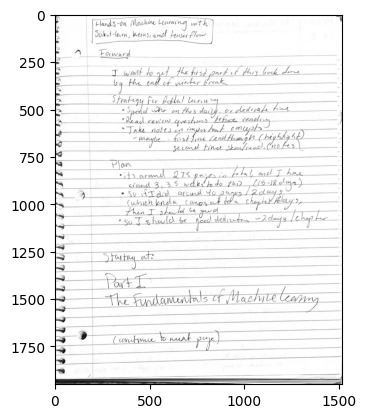

In [7]:
test_image_path = r'datasets\dataset\images\note-transfer ch1-6_Page_01_Image_0001.jpg'
test_image = cv2.imread(test_image_path)
test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2GRAY)
plt.imshow(test_image, cmap='gray')

Get our result (which contains the bounding boxes we need)

In [43]:
result = model.predict(test_image_path)


image 1/1 C:\Users\gjbur\Desktop\Code\note-transfer\development\dataset\images\note-transfer ch1-6_Page_01_Image_0001.jpg: 1024x800 None77.7ms
Speed: 13.5ms preprocess, 77.7ms inference, 7.4ms postprocess per image at shape (1, 3, 1024, 800)


In [44]:
for box in result[0].obb.xywhr:
    print(box)

tensor([ 824.3023,  945.6768,  386.6688, 1220.0867,    1.5527], device='cuda:0')
tensor([8.2127e+02, 5.7244e+02, 1.1545e+03, 3.7778e+02, 7.6703e-03], device='cuda:0')
tensor([ 817.2875, 1506.0520,  146.9489, 1248.2174,    1.5600], device='cuda:0')
tensor([6.1273e+02, 1.7146e+03, 6.3765e+02, 1.3993e+02, 1.5371e-02], device='cuda:0')
tensor([5.2153e+02, 8.4183e+01, 7.8814e+02, 1.3886e+02, 1.9718e-02], device='cuda:0')
tensor([ 390.2332, 1299.0880,  129.1441,  262.5409,    1.5601], device='cuda:0')
tensor([8.2739e+02, 3.2087e+02, 1.1010e+03, 1.2405e+02, 1.4331e-02], device='cuda:0')
tensor([538.1173,  97.5413, 321.5099, 544.2606,   0.9020], device='cuda:0')


Now we can use these results (x_center, y_center, width, height, angle) as the crops to our original image. We use opencv to first rotate the original image and crop it.

In [45]:
# Takes image and crop vars, returns cropped image
def crop_from_obb(image, xywhr):
    x_center, y_center, width, height, theta = xywhr.tolist()

    # Transformation for rotation, rotate image
    rotation_matrix = cv2.getRotationMatrix2D((x_center, y_center), np.degrees(theta), 1.0)
    rotated_image = cv2.warpAffine(image, rotation_matrix, (image.shape[1], image.shape[0]))

    # Crop the rotated image
    x_corner, y_corner = int(x_center - width/2), int(y_center - height/2)
    cropped_image = rotated_image[y_corner:y_corner+int(height), x_corner:x_corner+int(width)]

    # Rotate to flat if needed
    if theta > 1: # Might want to change based on height and width or somethign eventually
        cropped_image = cv2.rotate(cropped_image, cv2.ROTATE_90_CLOCKWISE)

    return cropped_image


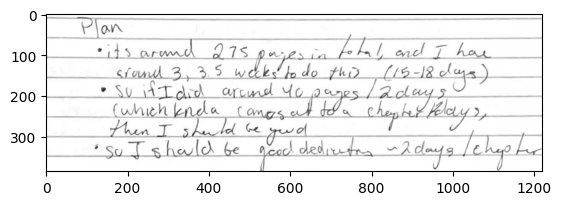

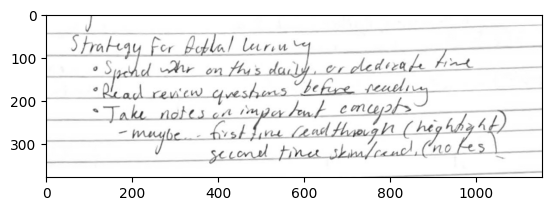

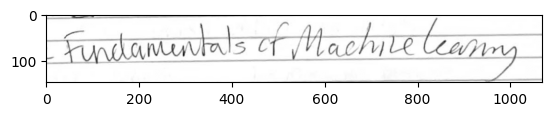

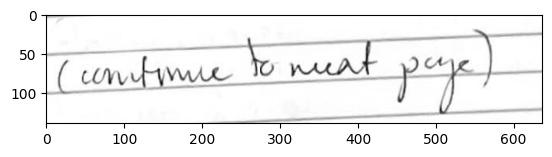

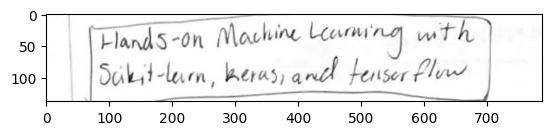

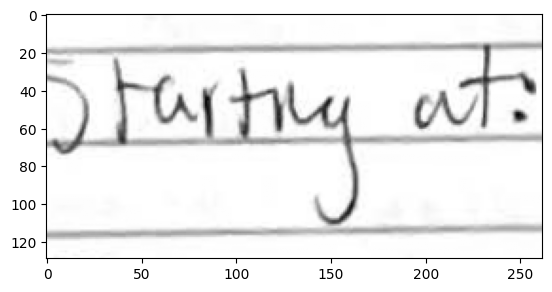

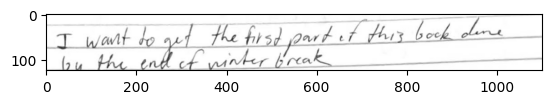

C:\Users\gjbur\AppData\Local\Temp\ipykernel_17380\3008140404.py:3: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.imshow(cropped, cmap='gray')


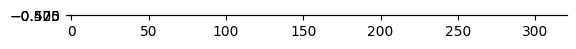

In [59]:
for xywhr in result[0].obb.xywhr:
    cropped = crop_from_obb(test_image, xywhr)
    plt.imshow(cropped, cmap='gray')
    plt.show()
    

Alright so some issues with rotation that we put a quick fix on. But overall it is possible to segment out these bounding boxes. And with better models, we'll be able to segment much better and more generalized.

## Regular Bounding Boxes

These just have their four corners, so you can just chop them with simple matrix slicing.

In [67]:
# Takes image and normal bounding box (no rotation) bounds (top left, bottom right points)
# Returns the cropped image
def crop_from_bb(image, xyxy):
    x1, y1, x2, y2 = xyxy.tolist()
    x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
    return image[y1:y2+1, x1:x2+1]

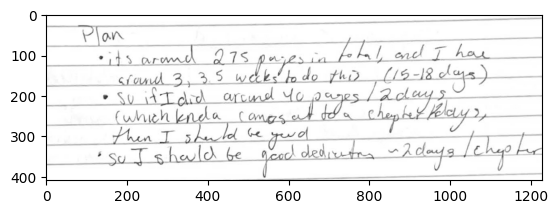

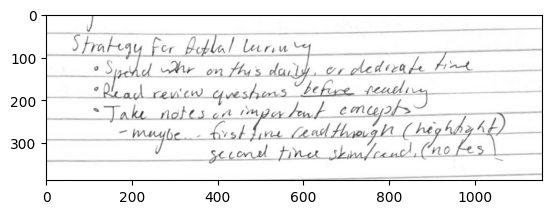

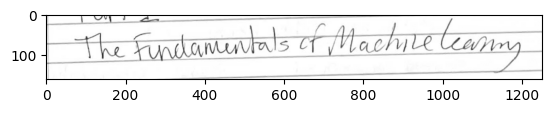

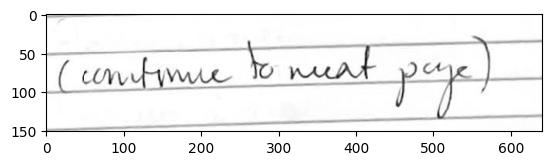

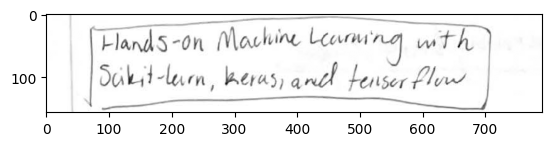

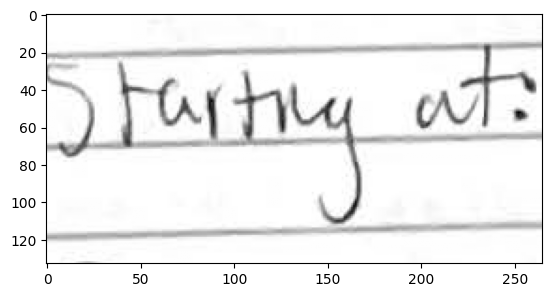

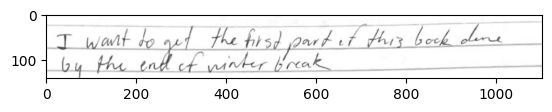

C:\Users\gjbur\AppData\Local\Temp\ipykernel_17380\118592834.py:3: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.imshow(cropped, cmap='gray')


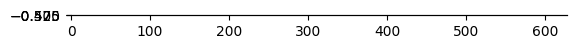

In [68]:
for xyxy in result[0].obb.xyxy:
    cropped = crop_from_bb(test_image, xyxy)
    plt.imshow(cropped, cmap='gray')
    plt.show()

Looks good! Of course, the segmentation models will need a little work.

# Second Step

Now that we have the first step of larger sections, we can get into the second step, which is segmentation by line.

## Creating the Dataset

Well, we want to be able to train our model on actual second-step segmentations. So we can take our OBB labels and images, utilize the functions we just made, and save some new, cropped images for our second-set dataset

In [15]:
# Get paths to each
images_folder = Path('datasets/large-section-dataset/data/images/train')
labels_folder = Path('datasets/large-section-dataset/data/labels/train')

In [29]:
import math

In [60]:
# Code to convert the x1,y1...x4,y4 labels to xc, yc, w, h, t for the cropping
def corners_to_xywhr(corners, width, height):
    corners = np.array(corners)

    # Scale to size
    corners[::2] *= width
    corners[1::2] *= height

    # Center
    xc = np.sum(corners[::2]) / 4.0
    yc = np.sum(corners[1::2]) / 4.0

    x1, y1, x2, y2, x3, y3, x4, y4 = corners
    # Dimensions (seems like they start at bottom left, go counter-clockwise)
    w = math.hypot(x2 - x1, y2 - y1)
    h = math.hypot(x3 - x2, y3 - y2)

    # Angle
    theta = math.atan2(y2-y1,x2-x1)

    return np.array([xc, yc, w, h, theta])


In [61]:
# Read off pairs of image, label files, saving new labels to output
output_folder = Path('datasets/by-section/data/images')

for image_name, label_name in zip(os.listdir(images_folder), os.listdir(labels_folder)):
    image_path, label_path = os.path.join(images_folder, image_name), os.path.join(labels_folder, label_name)

    # Load image, change to black and white
    image = cv2.imread(image_path, cv2.IMREAD_ANYCOLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Load labels, iterate through each, save new images
    count = 0
    with open(label_path, 'r') as label_file:
        for line in label_file:
            # Read and convert bounds to xc, yc, width, height, angle
            bounds = list(map(float, line.split()))[1:]
            xywhr = corners_to_xywhr(bounds, image.shape[1], image.shape[0])

            # Get cropped image, save into new folder
            cropped = crop_from_obb(image=image, xywhr=xywhr)
            cropped = cv2.cvtColor(cropped, cv2.COLOR_GRAY2BGR)

            output_name = f"{image_name[:-4]}-{count}{image_name[-4:]}"
            output_path = os.path.join(output_folder, output_name)
            cv2.imwrite(output_path, cropped)

            count += 1


## Training Smaller Segmentations

In [14]:
# Load the models
nano_model = YOLO('yolo11n.pt')

# Define function for training, validation
def train_model(model, yaml_path):
    result = model.train(
        data=yaml_path,
        epochs=50,
        project='runs/line-bb-real'
    )

    return result.results_dict

model_results = []
yaml_path = Path(r'datasets\by-section\data.yaml')

for model in [nano_model]:
    results = train_model(model, yaml_path)
    model_results.append(results)

New https://pypi.org/project/ultralytics/8.3.204 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets\by-section\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, op

train: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\by-section\data\labels\train.cache... 154 images, 0 backgrounds, 0 corrupt: 100%|██████████| 154/154 [00:00<?, ?it/s]


val: Fast image access  (ping: 0.10.1 ms, read: 51.725.9 MB/s, size: 45.1 KB)


val: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\by-section\data\labels\train.cache... 154 images, 0 backgrounds, 0 corrupt: 100%|██████████| 154/154 [00:00<?, ?it/s]


Plotting labels to runs\line-bb\train\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001111, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs\line-bb\train
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      50/50      2.48G     0.8955      1.546      1.082         29        640: 100%|██████████| 10/10 [00:02<00:00,  4.36it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:01<00:00,  4.66it/s]

                   all        154        440      0.757      0.647      0.637      0.472



50 epochs completed in 0.077 hours.
Optimizer stripped from runs\line-bb\train\weights\last.pt, 5.5MB
Optimizer stripped from runs\line-bb\train\weights\best.pt, 5.5MB

Validating runs\line-bb\train\weights\best.pt...
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
YOLO11n summary (fused): 100 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:01<00:00,  2.65it/s]


                   all        154        440      0.757      0.648      0.636      0.471
                Header         46         48      0.833      0.935      0.916      0.691
      Unordered Bullet         60        159      0.537      0.722      0.639      0.483
        Ordered Bullet          3         12          1          0     0.0826     0.0644
                  Text         91        199      0.573      0.719      0.663      0.467
                Figure         21         22      0.842      0.864      0.881      0.652
Speed: 0.2ms preprocess, 2.3ms inference, 0.0ms loss, 4.3ms postprocess per image
Results saved to runs\line-bb\train


Maybe not enough data, maybe more epochs needed. But at least it kind of works!

Let's create training, testing, and validation. Then we can really train this and see if it works

In [10]:
original_dir = os.getcwd()
dataset_path = Path(r"C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\by-section")
os.chdir(dataset_path)

# Load the models
nano_model = YOLO('yolo11n.pt')

# Define function for training, validation
def train_model(model, yaml_path):
    result = model.train(
        data=yaml_path,
        epochs=100,
        project='runs/'
    )

    return result.results_dict

yaml_path = Path(r'data_split.yaml')
results = train_model(nano_model, yaml_path)

os.chdir(original_dir)

New https://pypi.org/project/ultralytics/8.3.211 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data_split.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, op

train: Scanning data\labels\train... 122 images, 0 backgrounds, 0 corrupt: 100%|██████████| 122/122 [00:00<00:00, 331.90it/s]

train: New cache created: data\labels\train.cache


KeyboardInterrupt: 

In [11]:
# Test it as well
original_dir = os.getcwd()
dataset_path = Path(r"C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\by-section")
os.chdir(dataset_path)

# Load the model
model = YOLO(Path(r"runs\train\weights\best.pt"))

# Validate models\
val_result = model.val(
    data=yaml_path,
    project='runs/',
    split='val'
)
test_result = model.val(
    data=yaml_path,
    project='runs/'
)

print(val_result.results_dict)
print(test_result.results_dict)

os.chdir(original_dir)

Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
YOLO11n summary (fused): 100 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 93.052.3 MB/s, size: 43.0 KB)


val: Scanning data\labels\train... 16 images, 0 backgrounds, 0 corrupt: 100%|██████████| 16/16 [00:00<00:00, 186.34it/s]

val: New cache created: data\labels\train.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:10<00:00, 10.07s/it]


                   all         16         39      0.517      0.849      0.784      0.612
                Header          4          5      0.355        0.8      0.728      0.541
      Unordered Bullet          7         12      0.525      0.738      0.774      0.634
                  Text         11         21      0.502      0.857      0.641      0.376
                Figure          1          1      0.684          1      0.995      0.895
Speed: 2.1ms preprocess, 15.7ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to runs\val
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
val: Fast image access  (ping: 0.40.1 ms, read: 44.621.7 MB/s, size: 61.0 KB)


val: Scanning data\labels\train... 16 images, 0 backgrounds, 0 corrupt: 100%|██████████| 16/16 [00:00<00:00, 224.97it/s]

val: New cache created: data\labels\train.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:03<00:00,  3.97s/it]


                   all         16         48      0.561       0.77      0.676      0.438
                Header          4          4      0.593          1      0.725      0.417
      Unordered Bullet          9         25      0.707       0.52      0.748      0.504
                  Text          9         19      0.381      0.789      0.556      0.391
Speed: 1.8ms preprocess, 22.6ms inference, 0.0ms loss, 4.0ms postprocess per image
Results saved to runs\val2
{'metrics/precision(B)': np.float64(0.5166135506846752), 'metrics/recall(B)': np.float64(0.8487724545706882), 'metrics/mAP50(B)': np.float64(0.7842412247824755), 'metrics/mAP50-95(B)': np.float64(0.6116320045784439), 'fitness': np.float64(0.6288929265988471)}
{'metrics/precision(B)': np.float64(0.5605704208915315), 'metrics/recall(B)': np.float64(0.7698245614035087), 'metrics/mAP50(B)': np.float64(0.6764082904806611), 'metrics/mAP50-95(B)': np.float64(0.4375404184077242), 'fitness': np.float64(0.4614272056150179)}


Alright let's analyze this a little

- Seems like there's a lot of overprediction, with text, header, and ordered bullet getting predicted when something's actually background
- These might be mainly predictions over each other, not exclusive
- Having trouble distinguishing between text and unordered/ordered bullet

Let's see if we can discourage bounding box overlap. With a little bit of research I think I'll try working with the NMS parameters. Since it seems like multiple classes are overlapping, I want to enable NMS across classes, which is the 'agnostic_nms' parameter in ultraltyics. I can also change the IOU parameter to control how much overlap is needed to trigger it.

In [2]:
# Test it as well
original_dir = os.getcwd()
dataset_path = Path(r"C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\by-section")
os.chdir(dataset_path)

# Load the model
model = YOLO(Path(r"runs\train\weights\best.pt"))

yaml_path = Path(r'data_split.yaml')
# Validate models\
val_result = model.val(
    data=yaml_path,
    project='runs/nms',
    split='val',
    agnostic_nms=True
)
test_result = model.val(
    data=yaml_path,
    project='runs/nms',
    split='test',
    agnostic_nms=True
)

print(val_result.results_dict)
print(test_result.results_dict)

os.chdir(original_dir)

Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
YOLO11n summary (fused): 100 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 187.091.0 MB/s, size: 39.6 KB)


val: Scanning data\labels\train.cache... 16 images, 0 backgrounds, 0 corrupt: 100%|██████████| 16/16 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  1.16it/s]


                   all         16         39      0.678      0.705      0.674      0.521
                Header          4          5      0.424        0.6      0.623      0.476
      Unordered Bullet          7         12      0.811      0.362      0.429      0.336
                  Text         11         21      0.583      0.857       0.65      0.377
                Figure          1          1      0.894          1      0.995      0.895
Speed: 0.4ms preprocess, 10.4ms inference, 0.0ms loss, 20.6ms postprocess per image
Results saved to runs\nms\val3
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
val: Fast image access  (ping: 0.80.1 ms, read: 28.623.2 MB/s, size: 42.3 KB)


val: Scanning data\labels\train... 16 images, 0 backgrounds, 0 corrupt: 100%|██████████| 16/16 [00:00<00:00, 188.32it/s]

val: New cache created: data\labels\train.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:04<00:00,  4.41s/it]


                   all         16         48       0.66       0.68      0.549      0.339
                Header          4          4      0.614          1      0.725      0.382
      Unordered Bullet          9         25      0.892      0.331      0.387      0.255
                  Text          9         19      0.474      0.711      0.534       0.38
Speed: 1.4ms preprocess, 22.6ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to runs\nms\val4
{'metrics/precision(B)': np.float64(0.6780901741283099), 'metrics/recall(B)': np.float64(0.7047029992970298), 'metrics/mAP50(B)': np.float64(0.6742144447444768), 'metrics/mAP50-95(B)': np.float64(0.5211256658658187), 'fitness': np.float64(0.5364345437536845)}
{'metrics/precision(B)': np.float64(0.6599194034731038), 'metrics/recall(B)': np.float64(0.6804934000511697), 'metrics/mAP50(B)': np.float64(0.5490742469996953), 'metrics/mAP50-95(B)': np.float64(0.33884239866484384), 'fitness': np.float64(0.359865583498329)}


So it definitely helped with the overclassification issue, but now everything is being classified as text. This makes sense, because the difference is pretty hard to tell. As well, it's hard to tell is something is a header or not, especially when it's the only part of the section.

In order to address these issues, I'm thinking about slightly restructuring my models/data:

- Distinguish between header and body content with first-step section model
- No headers in second step, only label the ordered/unordered bullet/number/dash

With some change in planned parsing logic, these changes will still be viable

# Refining Two-step

We have some new changes that I've re-labelled with the dataset, and those should end up with good classfications. Here's the new idea:

Large Section:
- Classify either header and section
- Now everything is either header or 'body'

By Line:
- Refine each of those (either header or content) into classifications by line
- Can either be text, ordered bullet, unordered bullet, or a figure

## Retrain Large Section

In [10]:
autosplit(Path(r"datasets\refined-two-step\large-sections\data\images"))

Autosplitting images from datasets\refined-two-step\large-sections\data\images


100%|██████████| 19/19 [00:00<00:00, 786.33it/s]


In [2]:
model = YOLO('yolo11n-obb.pt')
yaml_path = Path(r"datasets\refined-two-step\large-sections\data.yaml")

results = model.train(
    data=yaml_path,
    project='runs/refining-two-step/large-section',
    epochs=200
)

KeyboardInterrupt: 

In [3]:
results.results_dict

{'metrics/precision(B)': np.float64(0.7772227481346978),
 'metrics/recall(B)': np.float64(0.8192518664216777),
 'metrics/mAP50(B)': np.float64(0.8759223936418887),
 'metrics/mAP50-95(B)': np.float64(0.6285266244588967),
 'fitness': np.float64(0.653266201377196)}

In [4]:
val_results = model.val(
    data=yaml_path,
    project='runs/refining-two-step/large-section',
    agnostic_nms=True
)

Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
YOLO11n-obb summary (fused): 109 layers, 2,654,113 parameters, 0 gradients, 6.6 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1336.3301.4 MB/s, size: 219.3 KB)


val: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\large-sections\data\labels\train.cache... 3 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3/3 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:02<00:00,  2.67s/it]


                   all          3         21      0.778      0.818      0.881      0.637
                Header          3          7      0.824      0.857      0.913      0.655
               Section          3         14      0.732       0.78      0.849      0.619
Speed: 9.0ms preprocess, 97.3ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to runs\refining-two-step\large-section\train32


## Retrain By Line

In [4]:
autosplit(Path(r"datasets\refined-two-step\by-line-12-19\data\images"))

Autosplitting images from datasets\refined-two-step\by-line-12-19\data\images


100%|██████████| 154/154 [00:00<00:00, 3689.01it/s]


In [3]:
model = YOLO('yolo11n.pt')
yaml_path = Path(r"datasets\refined-two-step\by-line-12-19\data.yaml")

results = model.train(
    data=yaml_path,
    project='runs/refining-two-step/by-line-12-19',
    epochs=200
)

New https://pypi.org/project/ultralytics/8.3.240 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets\refined-two-step\by-line-12-19\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, 

train: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\by-line\data\labels\train.cache... 133 images, 0 backgrounds, 0 corrupt: 100%|██████████| 133/133 [00:00<?, ?it/s]


val: Fast image access  (ping: 0.20.0 ms, read: 62.028.4 MB/s, size: 46.5 KB)


val: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\by-line\data\labels\train... 21 images, 0 backgrounds, 0 corrupt: 100%|██████████| 21/21 [00:00<00:00, 1166.43it/s]

val: New cache created: C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\by-line\data\labels\train.cache


...

    200/200       2.7G     0.7744     0.5799     0.9737         18        640: 100%|██████████| 9/9 [00:01<00:00,  5.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  8.03it/s]

                   all         21         81      0.914      0.929      0.964      0.624



200 epochs completed in 0.128 hours.
Optimizer stripped from runs\refining-two-step\by-line-12-19\train\weights\last.pt, 5.5MB
Optimizer stripped from runs\refining-two-step\by-line-12-19\train\weights\best.pt, 5.5MB

Validating runs\refining-two-step\by-line-12-19\train\weights\best.pt...
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
YOLO11n summary (fused): 100 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  7.91it/s]


                   all         21         81      0.852      0.933      0.965      0.647
      Unordered Bullet         10         20      0.948       0.91      0.938      0.443
                  Text         18         58      0.945      0.889      0.961      0.667
                Figure          3          3      0.664          1      0.995       0.83
Speed: 0.1ms preprocess, 0.9ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs\refining-two-step\by-line-12-19\train


In [4]:
results.results_dict

{'metrics/precision(B)': np.float64(0.8524111826881079),
 'metrics/recall(B)': np.float64(0.9329882336026536),
 'metrics/mAP50(B)': np.float64(0.9645319076375624),
 'metrics/mAP50-95(B)': np.float64(0.6469402202044872),
 'fitness': np.float64(0.6786993889477947)}

In [10]:
val_results = model.val(
    data=yaml_path,
    split='val',
    project='runs/refining-two-step/by-line-12-19',
    name='val',
    agnostic_nms=True,
    iou=0.5
)

Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 403.1357.2 MB/s, size: 46.1 KB)


val: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\by-line\data\labels\train.cache... 21 images, 0 backgrounds, 0 corrupt: 100%|██████████| 21/21 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:02<00:00,  1.23s/it]


                   all         21         81      0.923      0.943      0.947      0.613
      Unordered Bullet         10         20      0.949       0.95      0.938      0.423
                  Text         18         58      0.933      0.879      0.909      0.618
                Figure          3          3      0.885          1      0.995      0.798
Speed: 2.4ms preprocess, 14.2ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs\refining-two-step\by-line-12-19\val


In [6]:
val_results.results_dict

{'metrics/precision(B)': np.float64(0.9225858342659468),
 'metrics/recall(B)': np.float64(0.943103448275862),
 'metrics/mAP50(B)': np.float64(0.9472595855778154),
 'metrics/mAP50-95(B)': np.float64(0.6130314524110261),
 'fitness': np.float64(0.646454265727705)}

Now we can see, by line is much better, and the overall section is about the same with some more epochs.

Obviosuly our performance can be enhanced with more data, but with what we have, our results are pretty good!

Now, we want to put this together into a page-processing pipeline.

# Full Page Segmentation

Now that we have our two-step procress, we can put this together to segement a whole page.

## Naive Approach

First, we'll just chain each of the models together, ending up with an ordered list of content. No labels, just line-by-line segmentations.

In [1]:
# Takes xywhr and makes sure that it isn't the wrong angle
def normalize_xywhr(xywhr):
    x_center, y_center, width, height, theta = xywhr.tolist()
    if theta > (1/4)*np.pi or theta < (-1/4)*np.pi:
        temp = width
        width = height
        height = temp
        theta -= np.sign(theta)*(np.pi/2)

    return np.array([x_center, y_center, width, height, theta])

In [2]:
# Takes image and crop vars, returns cropped image
def crop_from_obb(image, xywhr):
    xywhr = normalize_xywhr(xywhr)
    x_center, y_center, width, height, theta = xywhr.tolist()

    # Transformation for rotation, rotate image
    rotation_matrix = cv2.getRotationMatrix2D((x_center, y_center), np.degrees(theta), 1.0)
    rotated_image = cv2.warpAffine(image, rotation_matrix, (image.shape[1], image.shape[0]))

    # Crop the rotated image
    x_corner, y_corner = int(x_center - width/2), int(y_center - height/2)
    cropped_image = rotated_image[y_corner:y_corner+int(height), x_corner:x_corner+int(width)]

    return cropped_image

In [3]:
# Takes image and normal bounding box (no rotation) bounds (top left, bottom right points)
# Returns the cropped image
def crop_from_bb(image, xyxy):
    x1, y1, x2, y2 = xyxy.tolist()
    x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
    return image[y1:y2+1, x1:x2+1]

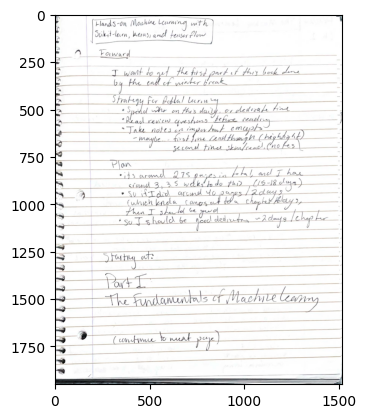

In [6]:
test_image_path = r"datasets\large-section-dataset\data\images\train\note-transfer ch1-6_Page_01_Image_0001.jpg"
test_image = cv2.imread(test_image_path, cv2.IMREAD_ANYCOLOR)
plt.imshow(test_image)

In [7]:
section_model = YOLO(r"runs\refining-two-step\large-section\train2\weights\best.pt")
line_model = YOLO(r"runs\refining-two-step\by-line-12-19\train\weights\best.pt")

0: 1024x800 None56.9ms
Speed: 8.9ms preprocess, 56.9ms inference, 2.9ms postprocess per image at shape (1, 3, 1024, 800)

0: 160x640 2 Texts, 10.0ms
Speed: 0.9ms preprocess, 10.0ms inference, 1.3ms postprocess per image at shape (1, 3, 160, 640)
Overall Image:


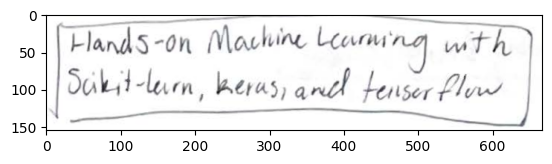

Children:


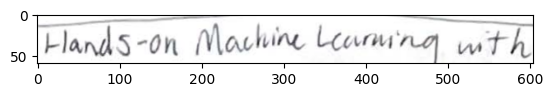

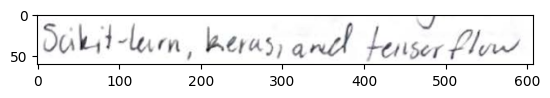


0: 256x640 1 Text, 11.3ms
Speed: 1.8ms preprocess, 11.3ms inference, 1.6ms postprocess per image at shape (1, 3, 256, 640)
Overall Image:


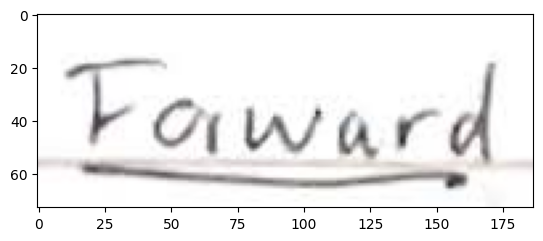

Children:


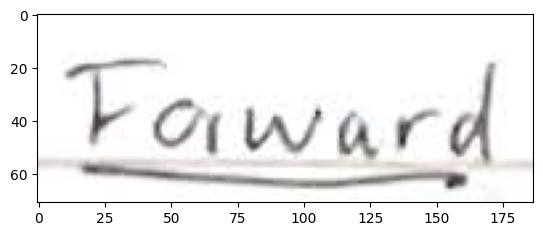


0: 96x640 2 Texts, 9.1ms
Speed: 1.3ms preprocess, 9.1ms inference, 1.3ms postprocess per image at shape (1, 3, 96, 640)
Overall Image:


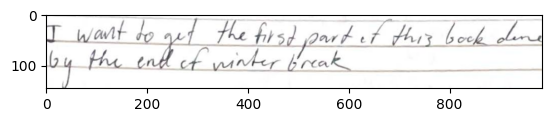

Children:


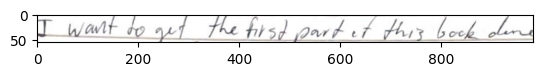

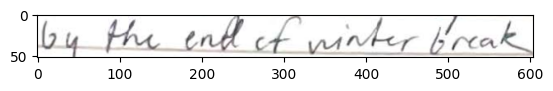


0: 224x640 4 Unordered Bullets, 7 Texts, 14.4ms
Speed: 1.7ms preprocess, 14.4ms inference, 1.3ms postprocess per image at shape (1, 3, 224, 640)
Overall Image:


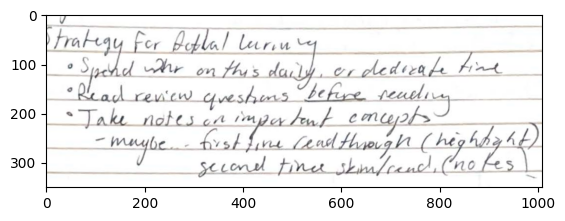

Children:


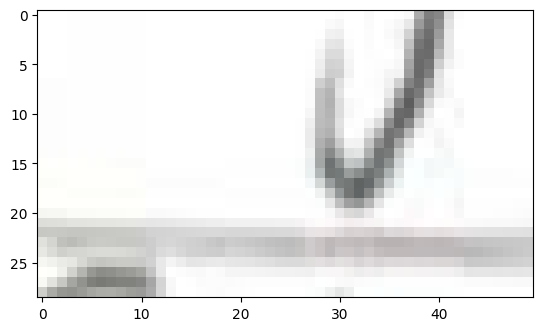

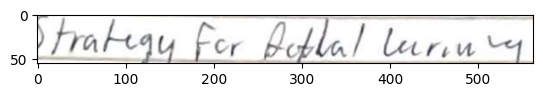

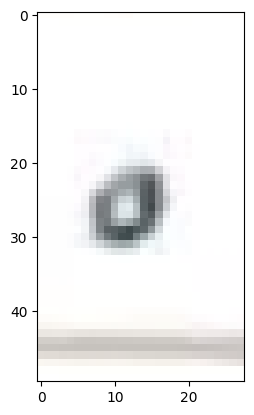

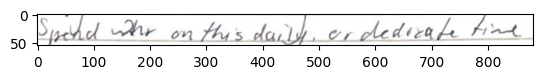

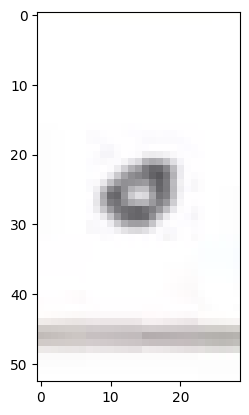

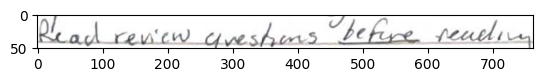

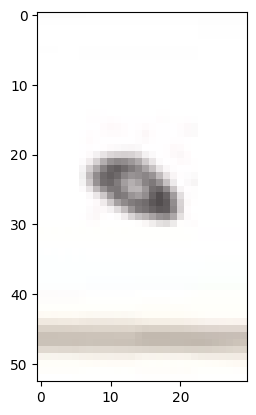

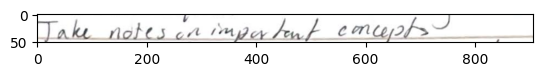

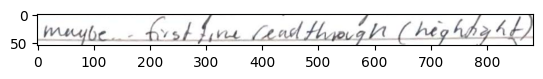

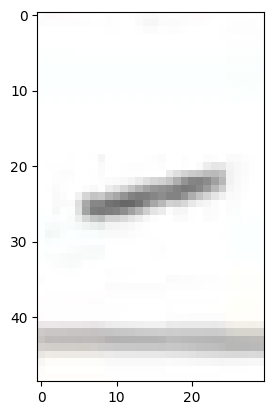

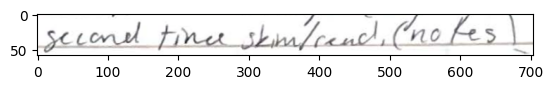


0: 256x640 3 Unordered Bullets, 7 Texts, 11.9ms
Speed: 1.7ms preprocess, 11.9ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 640)
Overall Image:


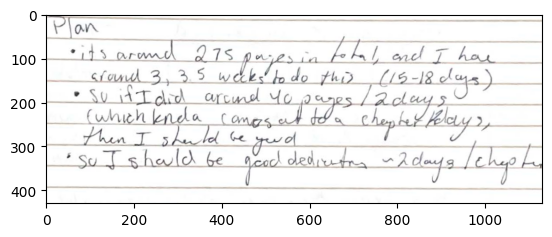

Children:


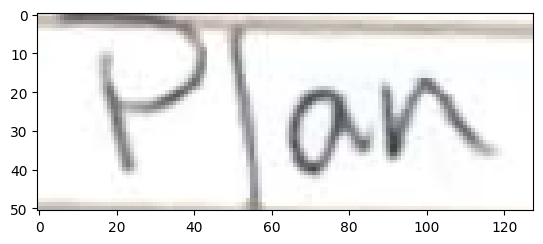

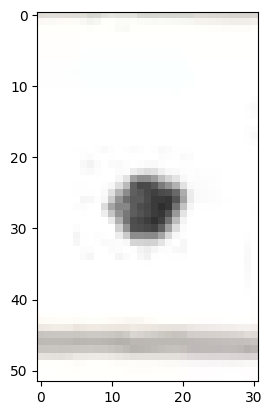

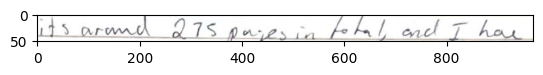

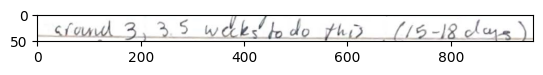

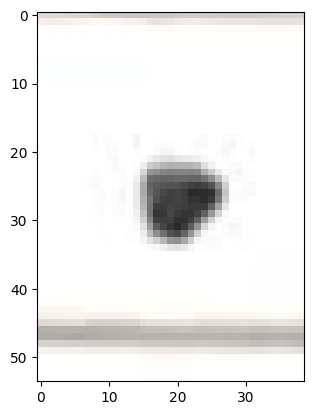

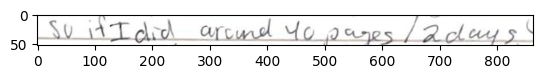

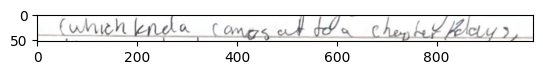

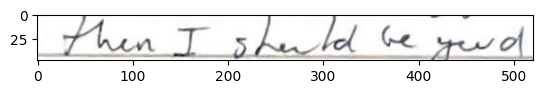

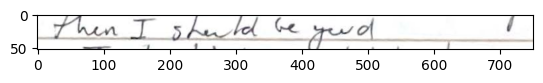

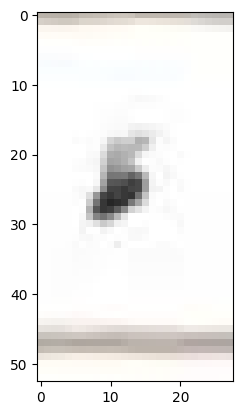


0: 256x640 1 Text, 12.0ms
Speed: 1.5ms preprocess, 12.0ms inference, 1.3ms postprocess per image at shape (1, 3, 256, 640)
Overall Image:


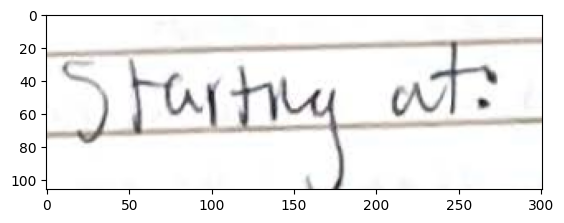

Children:


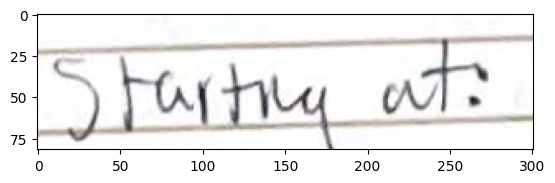


0: 224x640 1 Text, 10.7ms
Speed: 1.2ms preprocess, 10.7ms inference, 1.3ms postprocess per image at shape (1, 3, 224, 640)
Overall Image:


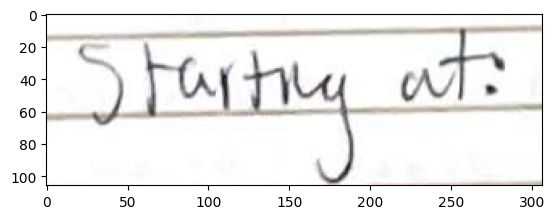

Children:


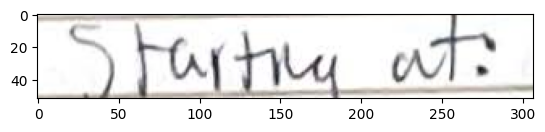


0: 320x640 1 Figure, 18.3ms
Speed: 2.2ms preprocess, 18.3ms inference, 1.3ms postprocess per image at shape (1, 3, 320, 640)
Overall Image:


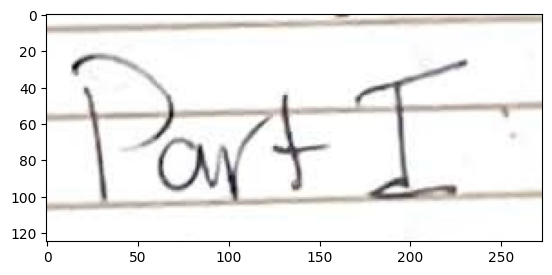

Children:


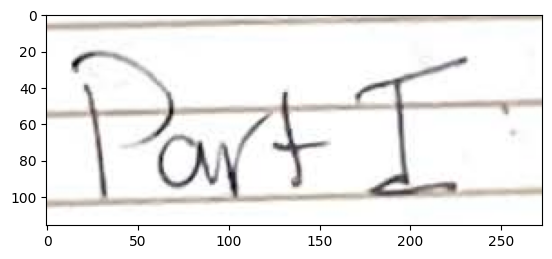


0: 128x640 2 Texts, 13.2ms
Speed: 3.0ms preprocess, 13.2ms inference, 1.6ms postprocess per image at shape (1, 3, 128, 640)
Overall Image:


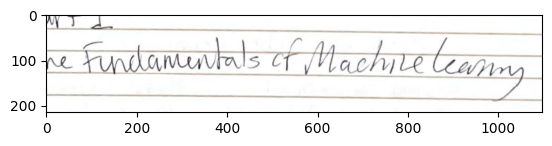

Children:


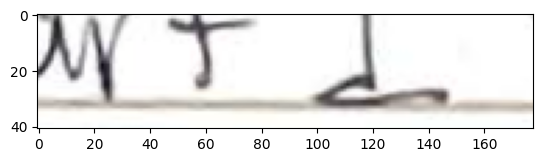

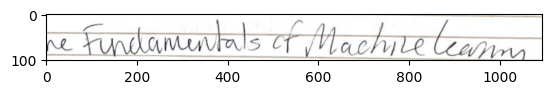


0: 192x640 1 Text, 14.3ms
Speed: 2.6ms preprocess, 14.3ms inference, 1.4ms postprocess per image at shape (1, 3, 192, 640)
Overall Image:


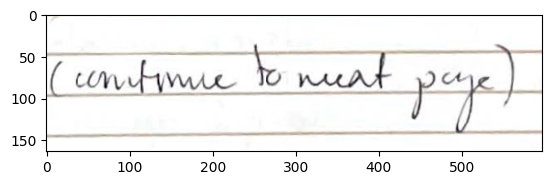

Children:


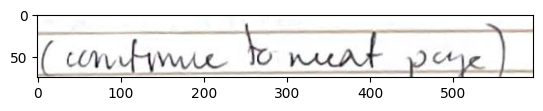

In [549]:
results = []

section_result = section_model.predict(test_image)
if section_result is None or len(section_result) == 0:
    print('No result!')
section_result = section_result[0]
if section_result.obb is None:
    print('No OBB!')

for xywhr in sorted(section_result.obb.xywhr, key=lambda x: x[1]):
    # First step is the section
    cropped_image = crop_from_obb(test_image, xywhr)

    if cropped_image.shape[0] == 0 or cropped_image.shape[1] == 0:
        print(f'Incompatible crop: {cropped_image.shape}')
        continue

    # Then segment by line after each section
    line_result = line_model.predict(cropped_image)

    print('Overall Image:')
    plt.imshow(cropped_image)
    plt.show()
    print('Children:')

    if line_result is None or len(line_result) == 0:
        print('No line result!')
    line_result = line_result[0]
    if line_result.boxes is None:
        print('No boxes!')

    for xyxy in sorted(line_result.boxes.xyxy, key=lambda x: x[1]):
        cropped_line = crop_from_bb(cropped_image, xyxy)
        if cropped_line.shape[0] == 0 or cropped_line.shape[1] == 0:
            print(f'Incompatible crop: {cropped_line.shape}')
            continue

        plt.imshow(cropped_line)
        plt.show()

Looks alright, but not great. I want to take a look at everythign being predicted and how they should be organized.

Going to probably use the AnyTree library to organize my stuff. Need to be able to deal with bullets somehow... since can't purely order on x vs y... since they're not fully aligned

## Toward a Better System

Utilize the AnyTree library, will help store the document structure and can store a lot of metadata as well!

We can first build the tree, and then build the markdown off of that tree (or any other systems that work)

A rough sketch:

1. Run through each section, every line in each section (store in list, each section gets its own sublist, associated with header)
2. Parse these lists/sublists, form into AnyTree for document structure using x, y, class
3. Convert document tree into markdown

### List of Segmentations

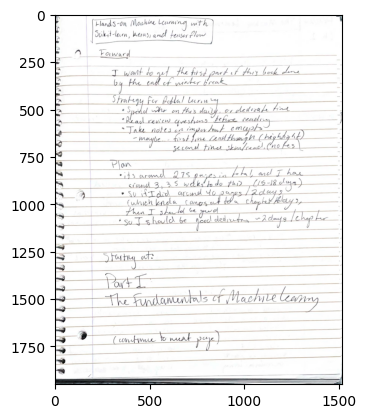

In [550]:
test_image_path = r"datasets\large-section-dataset\data\images\train\note-transfer ch1-6_Page_01_Image_0001.jpg"
test_image = cv2.imread(test_image_path, cv2.IMREAD_ANYCOLOR)
plt.imshow(test_image)

In [8]:
section_model = YOLO(r"runs\refining-two-step\large-section\train2\weights\best.pt")
line_model = YOLO(r"runs\refining-two-step\by-line-12-19\train\weights\best.pt")

In [9]:
def normalize_box(xywhr):
    x, y, w, h, r = xywhr
    if r > np.pi/4:
        w, h = h, w
        r -= np.pi/2
    return x, y, w, h, r

In [10]:
def xywhr2corner(xywhr):
    x, y, w, h, r = xywhr[0], xywhr[1], xywhr[2], xywhr[3], xywhr[4]

    x = x - 0.5*w*np.cos(r) + 0.5*h*np.sin(r)
    y = y - 0.5*w*np.sin(r) - 0.5*h*np.cos(r)

    return x, y

In [26]:
def get_page_segmentations(image):
    segmentations = []
    sid = 0

    section_result = section_model.predict(image, iou=0.5, agnostic_nms=True)
    if section_result is None or len(section_result) == 0:
        print('No result!')
    section_result = section_result[0]
    if section_result.obb is None:
        print('No OBB!')

    for class_id, xywhr in sorted(list(zip(section_result.obb.cls, section_result.obb.xywhr)), key=lambda res: res[1][1]):
        # First step is the section
        cropped_image = crop_from_obb(image, xywhr)

        if cropped_image.shape[0] == 0 or cropped_image.shape[1] == 0:
            print(f'Incompatible crop: {cropped_image.shape}')
            continue

        sec_class_name = section_result.names[int(class_id)]
        xywhr = normalize_box(xywhr.cpu().tolist())
        x, y = xywhr2corner(xywhr)
        sec_node = Node(
            sec_class_name,
            id=sid,
            is_section=True,
            cls_id=int(class_id.cpu()),
            x=x,
            y=y,
            x_c=xywhr[0],
            y_c=xywhr[1],
            w=xywhr[2],
            h=xywhr[3],
            r=xywhr[4]
        )
        segmentations.append(sec_node)
        sid += 1

        # Then segment by line after each section
        line_result = line_model.predict(cropped_image, iou=0.4, agnostic_nms=True)

        if line_result is None or len(line_result) == 0:
            print('No line result!')
        line_result = line_result[0]
        if line_result.boxes is None:
            print('No boxes!')

        for class_id, xyxy in sorted(list(zip(line_result.boxes.cls, line_result.boxes.xyxy)), key=lambda x: x[1][1]): # Sorted by height
            cropped_line = crop_from_bb(cropped_image, xyxy)
            if cropped_line.shape[0] == 0 or cropped_line.shape[1] == 0:
                print(f'Incompatible crop: {cropped_line.shape}')
                continue
            
            line_class_name = line_result.names[int(class_id)]
            xywhr = xyxy2xywh(xyxy).cpu().tolist()
            xywhr.append(0)
            xywhr = normalize_box(xywhr)
            x, y = xywhr2corner(xywhr)
            line_node = Node(
                line_class_name,
                id=sid,
                is_section=False,
                cls_id=int(class_id.cpu()),
                img=cropped_line,
                x=x,
                y=y,
                x_c=xywhr[0],
                y_c=xywhr[1],
                w=xywhr[2],
                h=xywhr[3],
                r=xywhr[3]
            )
            segmentations.append(line_node)
            sid += 1

    return segmentations 

In [44]:
segs = get_page_segmentations(test_image)


0: 1024x800 None57.2ms
Speed: 7.9ms preprocess, 57.2ms inference, 2.8ms postprocess per image at shape (1, 3, 1024, 800)

0: 160x640 2 Texts, 13.9ms
Speed: 1.5ms preprocess, 13.9ms inference, 3.9ms postprocess per image at shape (1, 3, 160, 640)

0: 256x640 1 Text, 35.3ms
Speed: 1.8ms preprocess, 35.3ms inference, 1.4ms postprocess per image at shape (1, 3, 256, 640)

0: 96x640 2 Texts, 12.3ms
Speed: 1.3ms preprocess, 12.3ms inference, 1.2ms postprocess per image at shape (1, 3, 96, 640)

0: 224x640 4 Unordered Bullets, 7 Texts, 34.2ms
Speed: 1.7ms preprocess, 34.2ms inference, 1.4ms postprocess per image at shape (1, 3, 224, 640)

0: 256x640 3 Unordered Bullets, 6 Texts, 16.7ms
Speed: 2.0ms preprocess, 16.7ms inference, 1.4ms postprocess per image at shape (1, 3, 256, 640)

0: 224x640 1 Text, 15.0ms
Speed: 1.7ms preprocess, 15.0ms inference, 1.2ms postprocess per image at shape (1, 3, 224, 640)

0: 320x640 1 Figure, 34.4ms
Speed: 1.3ms preprocess, 34.4ms inference, 1.9ms postprocess 

Header - (181.67,14.86) - -0.01
 - Text - (24.76,3.15)


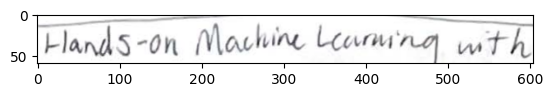

 - Text - (22.88,61.4)


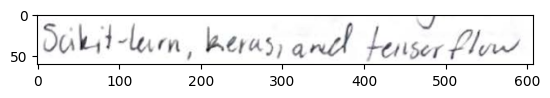

Header - (223.58,168.81) - 0.0
 - Text - (0.0,0.89)


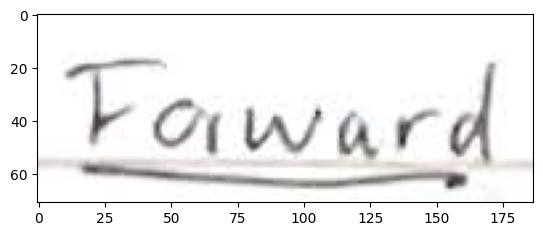

Section - (302.92,272.87) - -0.02
 - Text - (0.09,11.48)


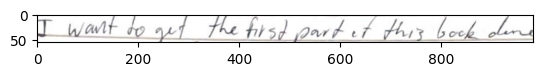

 - Text - (1.21,63.55)


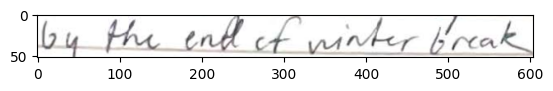

Section - (309.18,401.36) - -0.01
 - Text - (0.0,0.0)


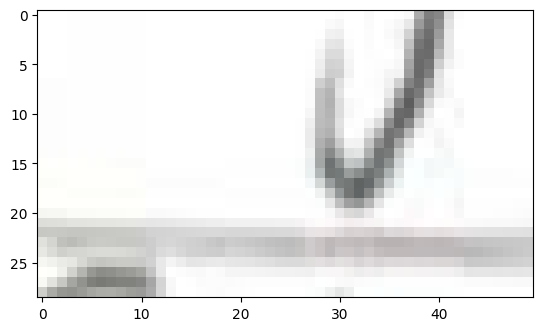

 - Text - (0.0,25.92)


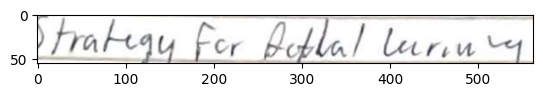

 - Unordered Bullet - (37.93,79.31)


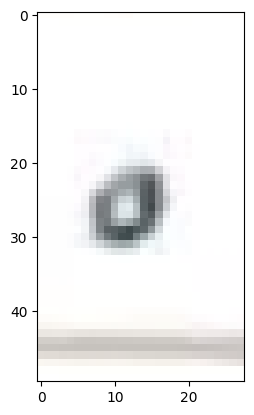

 - Text - (68.05,80.55)


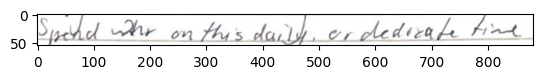

 - Unordered Bullet - (34.14,127.4)


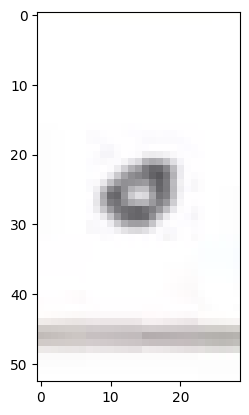

 - Text - (62.07,132.5)


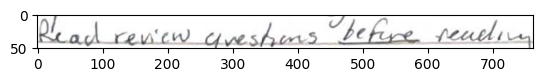

 - Unordered Bullet - (34.23,177.49)


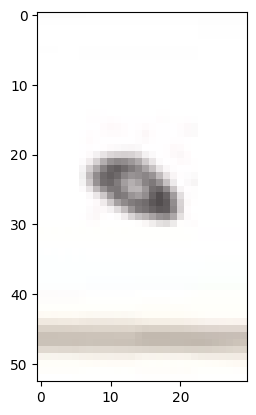

 - Text - (66.41,180.02)


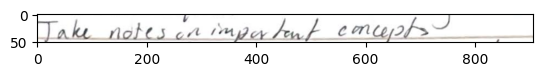

 - Text - (120.35,227.8)


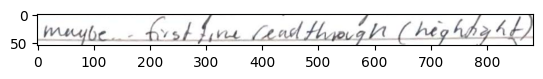

 - Unordered Bullet - (95.29,229.3)


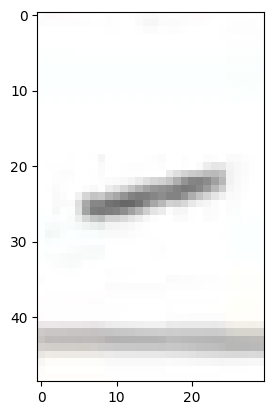

 - Text - (300.41,276.08)


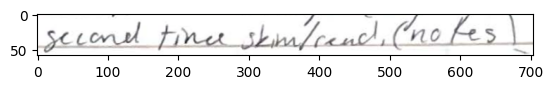

Section - (283.56,765.92) - -0.03
 - Text - (1.9,4.11)


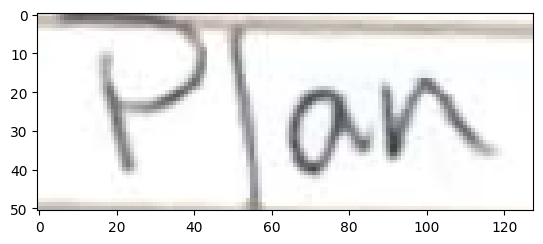

 - Unordered Bullet - (46.8,57.08)


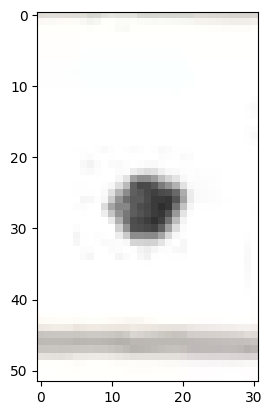

 - Text - (75.65,62.6)


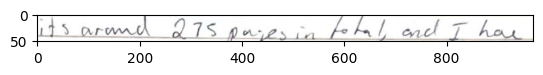

 - Text - (69.73,112.13)


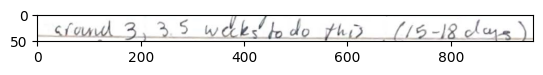

 - Unordered Bullet - (49.99,154.91)


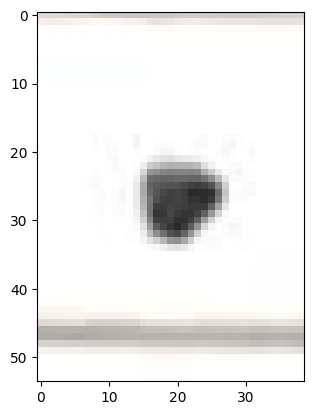

 - Text - (78.96,160.96)


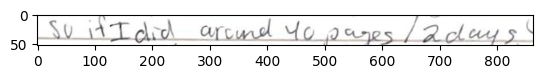

 - Text - (48.82,208.94)


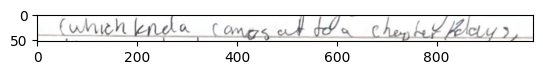

 - Text - (58.44,255.01)


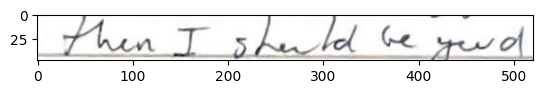

 - Unordered Bullet - (40.51,298.61)


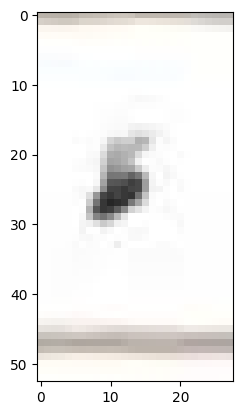

Header - (236.57,1241.05) - -0.0
 - Text - (0.83,12.7)


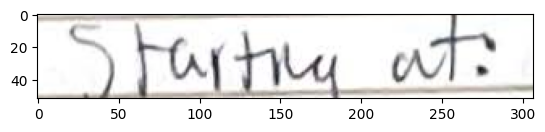

Section - (251.0,1343.46) - -0.0
 - Figure - (0.0,2.38)


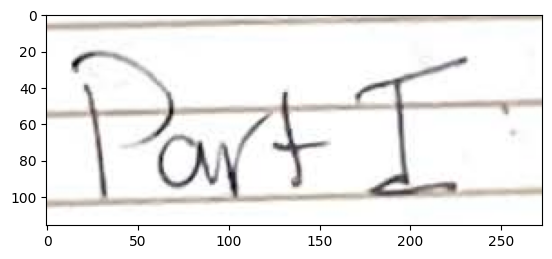

Section - (329.48,1415.33) - -0.03
 - Text - (0.0,0.0)


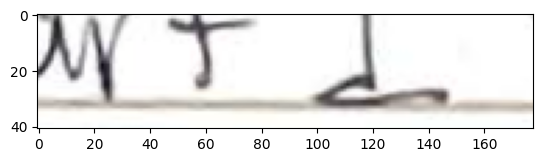

 - Text - (0.0,39.11)


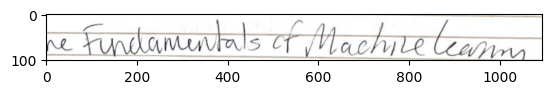

Section - (302.15,1642.82) - -0.02
 - Text - (0.01,25.72)


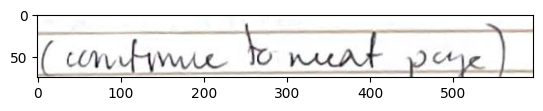

In [556]:
%matplotlib inline
for node in segs:
    if node.is_section:
        print(f"{node.name} - ({round(node.x,2)},{round(node.y,2)}) - {round(node.r, 2)}")
    else:
        print(f" - {node.name} - ({round(node.x,2)},{round(node.y,2)})")
        plt.imshow(node.img)
        plt.show()

Looking pretty solid! We have a good list, and its relatively sorted already. Now we have to build out the tree.

### Parsing the Tree

Need some quick way to differentiate "levels". Need to research some ways of quick clustering, or determining of the distance between two points that separates the clusters.

#### Sections

We'll focus on the sections first, since that's really what will situate the hierarchy (since each line within each section should be on the same line).

As a start, I think rotating the segmentation corners by the average rotation will help with the vertical alignment, since if there's an angle then the x axis isn't exactly what we're aligning to. 

In [557]:
sum_r = 0
sec_count = 0
for node in segs:
    if node.is_section:
        sum_r += node.r
        sec_count += 1
avg_r = sum_r / sec_count
avg_r

-0.01317668049306696

In [558]:
x_values = [node.x for node in segs if node.is_section]
y_values = [node.y for node in segs if node.is_section]
classes = [node.name for node in segs if node.is_section]

sec_xy = np.array([x_values, y_values]).T
print(sec_xy)
classes = np.array(classes)

angle = -avg_r
rot = np.array([
    [np.cos(angle), -np.sin(angle)],
    [np.sin(angle),  np.cos(angle)]
])
center = np.array([test_image.shape[1]/2, test_image.shape[0]/2])
sec_xy = (sec_xy - center) @ rot.T + center
sec_xy

[[     181.67      14.856]
 [     223.58      168.81]
 [     302.92      272.87]
 [     309.18      401.36]
 [     283.56      765.92]
 [     236.57        1241]
 [        251      1343.5]
 [     329.48      1415.3]
 [     302.15      1642.8]]


array([[     194.37,      7.3589],
       [     234.25,      161.85],
       [     312.21,      266.94],
       [     316.78,      395.51],
       [     286.35,       759.7],
       [     233.11,      1234.2],
       [     246.19,      1336.8],
       [     323.72,      1409.7],
       [     293.39,      1636.8]])

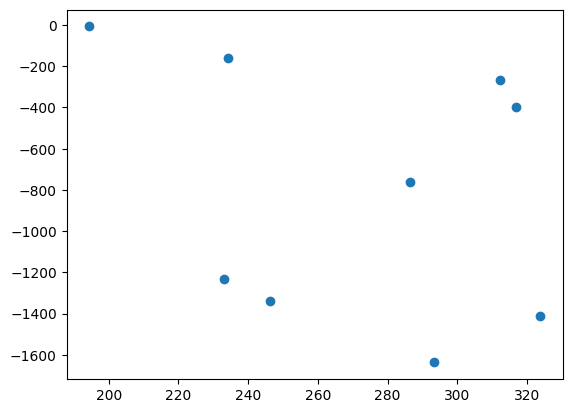

In [559]:
plt.scatter(x=sec_xy[:,0], y=-sec_xy[:,1])

<Axes: >

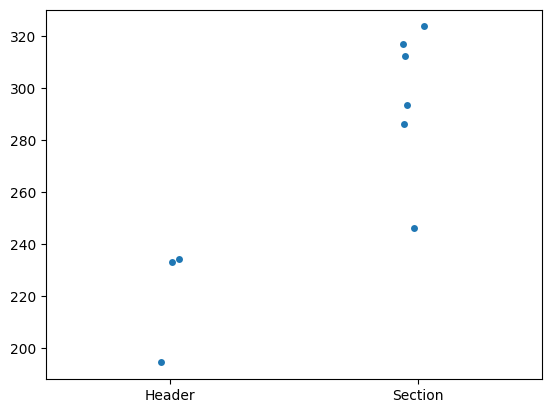

In [560]:
sns.stripplot(x=classes, y=sec_xy[:,0])

<Axes: >

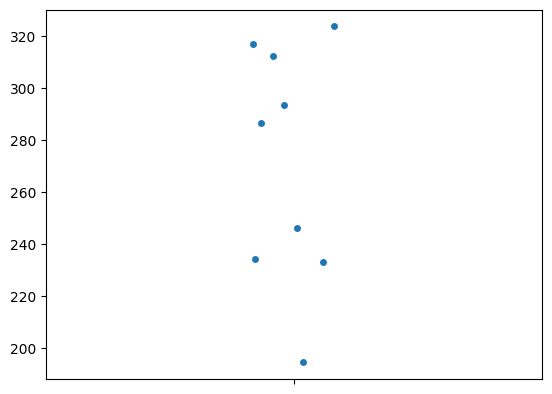

In [561]:
sns.stripplot(sec_xy[:,0])

You can tell that there's some decent clustering, so there might be something to work with.

Now, how to go about actuall doing that clustering? Do we want to cluster the x axes, label them beforeahnd, and then do parent assignment off of that? Or do we want to use the clusters to determine a dist-between, and then use that to determine if we'll go up/down a level at every node.

I think I'll start with this clusterring/labelling idea, since in first thoughts, there may be some challenges with information lost between steps. Something like a "margin creep" could start, where if you miss one section start then the rest don't look too bad. I'm also pretty sure for this amount of data, clustering on 1D can't be too bad.

Could look into some sort of gap clustering, but I'd have to see hwo setting the gap would be done efficiently and effectively. For now, let's see what dbscan can do.

In [562]:
x_values = sec_xy[:,0].reshape(-1, 1)
labels = DBSCAN(eps=38, min_samples=1).fit_predict(x_values)

<Axes: >

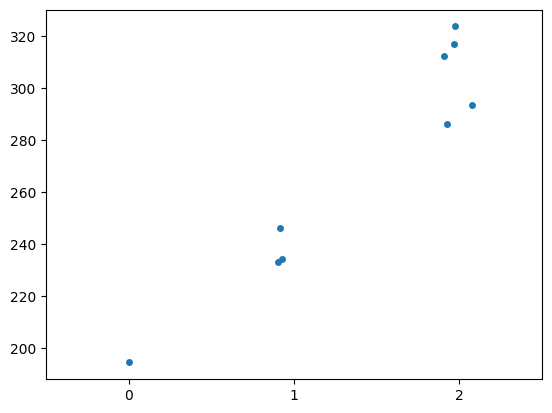

In [563]:
sns.stripplot(x=labels, y=sec_xy[:,0])

Looks like that works, but still needs the eps set. I'd wonder if gap clustering would work with similar gap compared to eps, or if its more sensitive. Wouldn't mind just using gap sorting (although would have to sort with respect to x beforehand)

In [564]:
def gap_cluster(x, gap):
    x = np.sort(x)
    labels = np.zeros(len(x), dtype=int)
    cluster = 0

    for i in range(1, len(x)):
        if x[i] - x[i-1] > gap:
            cluster += 1
        labels[i] = cluster

    return labels

<Axes: >

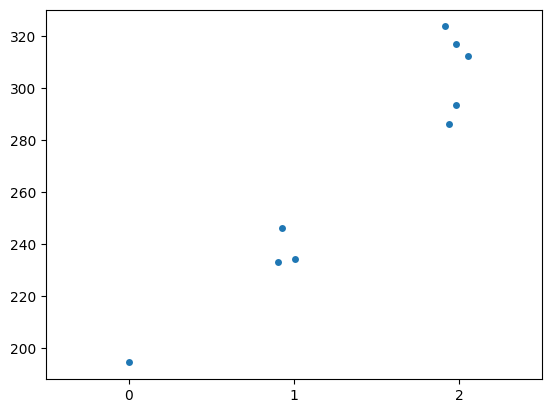

In [565]:
labels = gap_cluster(sorted(x_values), 38)
sns.stripplot(x=labels, y=sorted(sec_xy[:,0]))

Lower bound for epsilon and the gap are both 19, upper bounds are 38 as well.

Apperently this is because dbscan essentially becomes gap clustering one you do only one min sample. That intuition makes sense, I guess I'm not familiar enough with these yet to have that off the dome. But with time and learning I will.

So, either way, I really just need a good way to determine that gap. Let's look at the distribution of diffs and see if we can find some sort of way to get in that range.

In [566]:
x_sorted = np.array(sorted(sec_xy[:,0]))
diffs = np.diff(x_sorted)
diffs

array([     38.736,      1.1349,      11.947,      40.162,      7.0359,      18.824,      4.5654,      6.9363])

<Axes: >

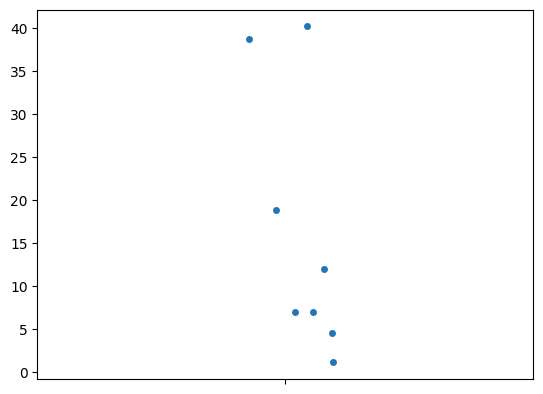

In [567]:
sns.stripplot(diffs)

{'whiskers': [<matplotlib.lines.Line2D at 0x1ee68564380>,
 'caps': [<matplotlib.lines.Line2D at 0x1ee68564830>,
 'boxes': [<matplotlib.lines.Line2D at 0x1ee68564170>],
 'medians': [<matplotlib.lines.Line2D at 0x1ee68564e00>],
 'fliers': [<matplotlib.lines.Line2D at 0x1ee68565040>],
 'means': []}

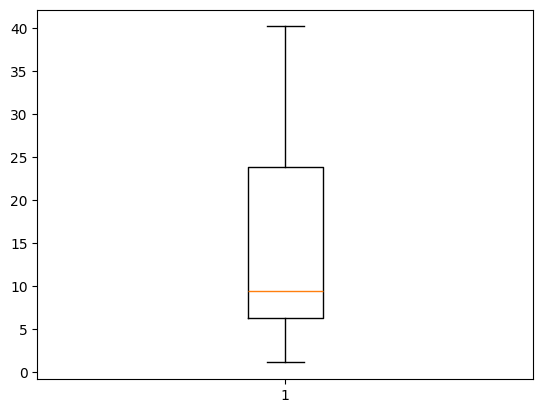

In [568]:
plt.boxplot(diffs)

We can see that the two separating diffs lie on the top end of what works for our data. So we can use the standard deviation and the mean to pick something in the middle of that large jump.

In [569]:
print(diffs.mean())
print(diffs.std())

16.167633823088202
14.313892313667477


In [570]:
gap = diffs.mean() + diffs.std()
gap

np.float64(30.48152613675568)

This one lies right in the middle of what works. We'll have to do more robustness testing later on, but for now, this will do.

I think for now, since we don't really have a need at the moment to sort by x value other than this gap clustering, we can just use dbscan instead, sinc ethey have similar results.

Okay, so other than jsut the logic of putting it together, we have the levels of our sections done (and the order is just the sorted y value)

#### Lines

The lines might be a little harder, mainly becuase of the bullets. I need to separate them by section (which is fine because they're inherently separated that way). 

Then I need to group together everything that's in a bullet distinguish between bullet and non-bullet groups, and the sectioning of the level of the bullet, and the sectioning of them level of the bullet.

I'll assume that all the text will be on the same level (the initial level right under the section), but bullets may be a different story. 

My initial idea:

- 2D Grouping System
- Vertical grouping to determine bullet groups
- Horizontal grouping to determine bullet levels

I can probably use the same horizontal grouping as I did with sections. But with vertical grouping, its going to be a little different, since there's logic with bullets to deal with

I'll be able to combine these sequentially so that we come out with a proper ordering. Each bullet node will have its text (and other bullets if needed) as children

In [571]:
line_sections = []

line_xs = []
line_ys = []

for node in segs:
    if node.is_section and len(line_xs) != 0:
        lines_xy = np.array([line_xs, line_ys]).T
        line_sections.append(lines_xy)
        line_xs = []
        line_ys = []
    elif not node.is_section:
        line_xs.append(node.x)
        line_ys.append(node.y)

line_sections

[array([[     24.763,      3.1536],
        [     22.883,      61.401]]),
 array([[          0,     0.89149]]),
 array([[    0.09082,      11.478],
        [     1.2096,      63.547]]),
 array([[          0,           0],
        [          0,       25.92],
        [     37.931,      79.306],
        [     68.054,      80.548],
        [     34.139,       127.4],
        [     62.069,       132.5],
        [     34.233,      177.49],
        [     66.407,      180.02],
        [     120.35,       227.8],
        [     95.295,       229.3],
        [     300.41,      276.08]]),
 array([[     1.8957,      4.1138],
        [     46.804,      57.081],
        [     75.645,      62.599],
        [     69.729,      112.13],
        [     49.989,      154.91],
        [     78.964,      160.96],
        [     48.822,      208.94],
        [     58.437,      255.01],
        [     40.513,      298.61]]),
 array([[    0.82996,      12.703]]),
 array([[          0,      2.3794]]),
 array([[     

Let's take a look at that fourth section

In [572]:
test_section = line_sections[3]
test_section

array([[          0,           0],
       [          0,       25.92],
       [     37.931,      79.306],
       [     68.054,      80.548],
       [     34.139,       127.4],
       [     62.069,       132.5],
       [     34.233,      177.49],
       [     66.407,      180.02],
       [     120.35,       227.8],
       [     95.295,       229.3],
       [     300.41,      276.08]])

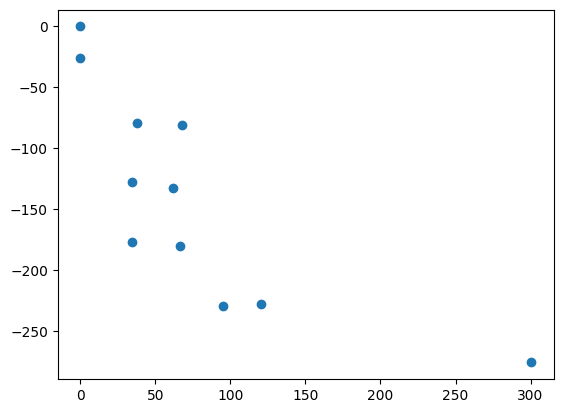

In [573]:
plt.scatter(x=test_section[:,0], y=-test_section[:,1])

<Axes: >

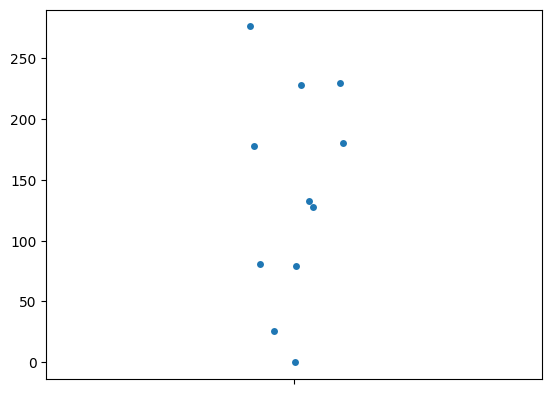

In [574]:
sns.stripplot(test_section[:, 1])

<Axes: >

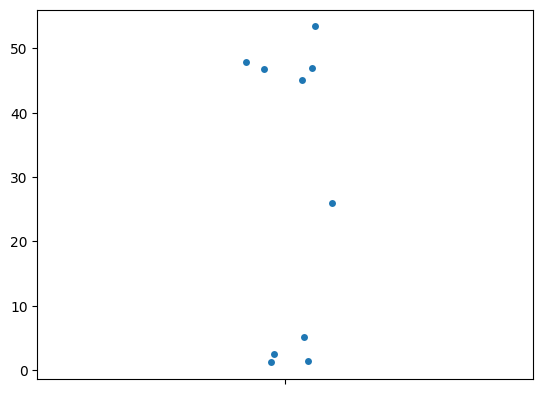

In [575]:
sns.stripplot(np.diff(test_section[:, 1]))

We see that for vertical clustering, our horizontal clustering doesn't work as much. This is becuase the distribution of diffs is different. This is something I'll have to take into account in the future once we start testing this on many pages.

For now though, we can just adapt our gap to not take the std into account, since the binary nature of this data is odd. This will also depend on how many bullets travel onto multiple lines. Because if they go for multiple, this distrubtion will change as well (skewing towards larger gaps). Need a way around that

Probably different algorithms out there for finding pairs vs clusters. Or at least different gap-finding with the same alg.

In [576]:
def find_pairs(values):
    diffs = np.diff(values)
    gap = int(diffs.mean())
    print(gap)

    values = values.reshape((-1, 1))
    labels = DBSCAN(eps=gap, min_samples=1).fit_predict(values)
    return labels

In [577]:
vertical_labels = find_pairs(test_section[:, 1])
vertical_labels

27


array([0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5])

In [578]:
def find_clusters(values):
    diffs = np.diff(values)
    gap = int(diffs.mean() + diffs.std())
    print(gap)

    values = values.reshape((-1, 1))
    labels = DBSCAN(eps=gap, min_samples=1).fit_predict(values)
    return labels

<Axes: >

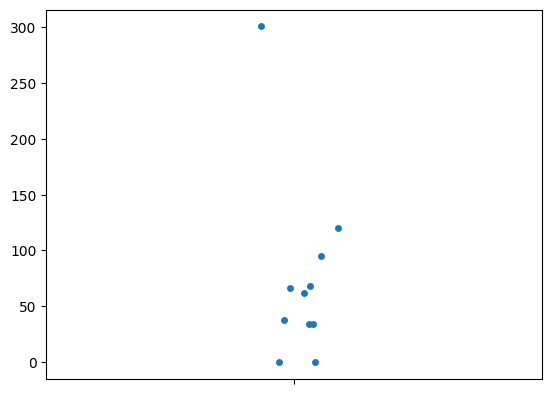

In [579]:
sns.stripplot(test_section[:, 0])

<Axes: >

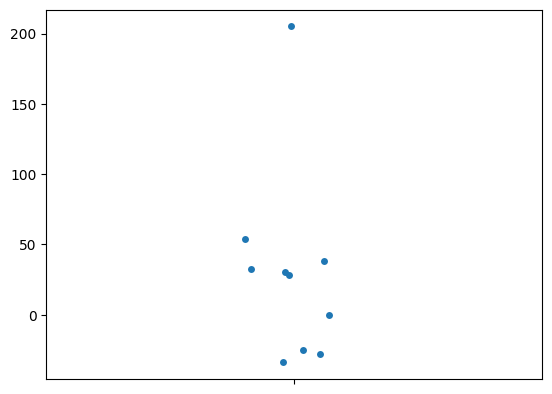

In [580]:
sns.stripplot(np.diff(test_section[:, 0]))

In [581]:
horizontal_labels = find_clusters(test_section[:,0])
horizontal_labels

95


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

This didn't deal with that one outlier very well, so I'll devise one to trim those off in a pretty standard way for now...

In [582]:
def find_clusters(values):
    diffs = np.diff(values)
    lower, upper = diffs.mean() - 1.5*diffs.std(), diffs.mean() + 1.5*diffs.std()
    diffs = diffs[(diffs > lower) & (diffs < upper)]
    gap = int(diffs.mean() + diffs.std())

    values = values.reshape((-1, 1))
    labels = DBSCAN(eps=gap, min_samples=1).fit_predict(values)
    return labels

In [583]:
horizontal_labels = find_clusters(test_section[:,0])
print(test_section[:,0])
horizontal_labels

[          0           0      37.931      68.054      34.139      62.069      34.233      66.407      120.35      95.295      300.41]


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

Now let's see how this worked...

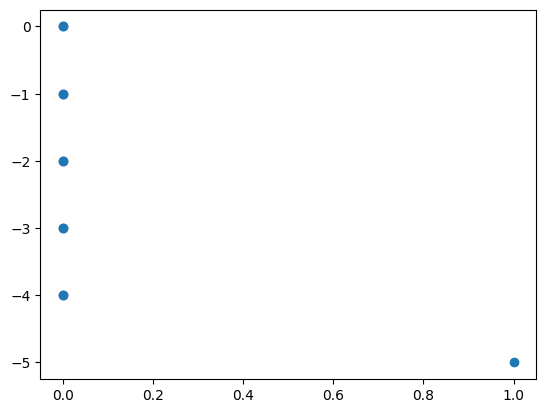

In [584]:
plt.scatter(x=horizontal_labels, y=-vertical_labels)

Okay, we're getting there. Maybe with some extra logic, this can work! Let's test on other set to see how it fairs on a different type of distribution.

In [585]:
test_section2 = line_sections[4]
test_section2

array([[     1.8957,      4.1138],
       [     46.804,      57.081],
       [     75.645,      62.599],
       [     69.729,      112.13],
       [     49.989,      154.91],
       [     78.964,      160.96],
       [     48.822,      208.94],
       [     58.437,      255.01],
       [     40.513,      298.61]])

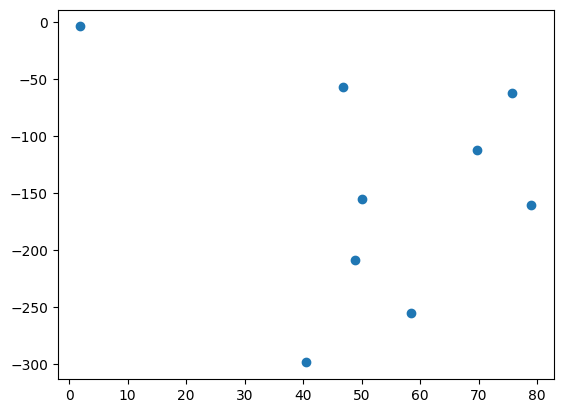

In [586]:
plt.scatter(x=test_section2[:,0], y=-test_section2[:,1])

In [587]:
vertical_labels2 = find_pairs(test_section2[:,1])
print(vertical_labels2)
horizontal_labels2 = find_clusters(test_section2[:,0])
print(horizontal_labels2)

36
[0 1 1 2 3 3 4 5 6]
[0 1 1 1 1 1 1 1 1]


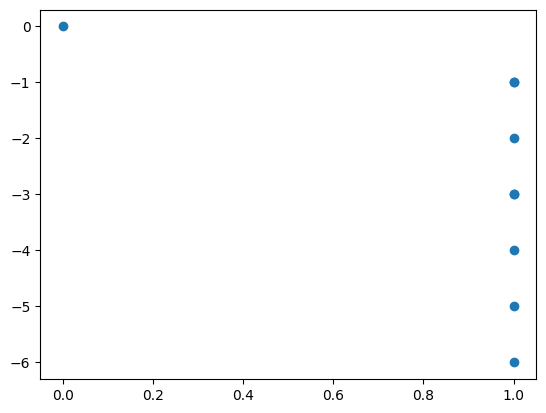

In [588]:
plt.scatter(x=horizontal_labels2, y=-vertical_labels2)

Overall, with some extra logic and care for tuning the clustering vs pairs, this looks pretty good! now, we must bring it all together, adding the class-based logic and parent mappings.

#### Putting It Together

I think the main issue that I'll have to deal with is to decide when to stop parsing as children of an unordered bullet.

Right now, I have the labels so that the ones below extend to where the bullet is. But I think I'll change it to that they don't, and we can just distinguish a new text on if it isn't indented compared to the others.

**^ Just retrained the by-line segmentation model on this new segmentation philosophy**

In [32]:
# Assuming already sorted
def gap_cluster(x, gap):
    labels = np.zeros(len(x), dtype=int)
    cluster = 0

    for i in range(1, len(x)):
        if x[i] - x[i-1] > gap:
            cluster += 1
        labels[i] = cluster

    return labels

In [33]:
# Finds pairs in already sorted valeus, helps with matching bullet and text
def find_pairs(values):
    if len(values) < 2:
        return [0]

    diffs = np.diff(values)
    if len(diffs) > 1:
        lower, upper = diffs.mean() - 2*diffs.std(), diffs.mean() + 2*diffs.std()
        diffs = diffs[(diffs > lower) & (diffs < upper)]
    gap = (diffs.min() + diffs.max())/2

    values = values.reshape((-1, 1))
    labels = gap_cluster(values, gap)
    return labels

In [34]:
test1 = np.array([0.05, 0.1, 0.9, 1, 2, 2.9, 3, 4, 4.7, 10, 10.1, 10.9, 11.1])
test2 = np.array([0.05, 0.1, 0.9, 2.1, 3, 3.15, 4.2, 5, 5.97, 7, 7.1, 49, 50, 50.1])

print(find_pairs(test1))
print(find_pairs(test2))

[0 0 1 1 2 3 3 4 5 6 6 7 7]
[0 0 1 2 3 3 4 5 6 7 7 8 9 9]


In [35]:
def find_clusters(values):
    if len(values) < 2:
        return [0]

    diffs = np.diff(sorted(values))
    if len(diffs) > 1:
        lower, upper = diffs.mean() - 2*diffs.std(), diffs.mean() + 2*diffs.std()
        diffs = diffs[(diffs > lower) & (diffs < upper)]
    else:
        return [0,0]
    gap = (diffs.min() + diffs.max())/2

    values = values.reshape((-1, 1))
    labels = DBSCAN(eps=gap, min_samples=1).fit_predict(values)
    return labels

In [36]:
test1 = np.array([0.1, 1.1, 0.9, 3, 2.7, 1.2, 1.1, 1.4, 4])
test2 = np.array([0.1, 0.5, 1, 1.1, 0.9, 0.4, 0])

print(find_clusters(test1))
print(find_clusters(test2))

[0 1 1 2 2 1 1 1 3]
[0 1 2 2 2 1 0]


[     181.67      223.58      302.92      309.18      283.56      236.57         251      329.48      302.15]


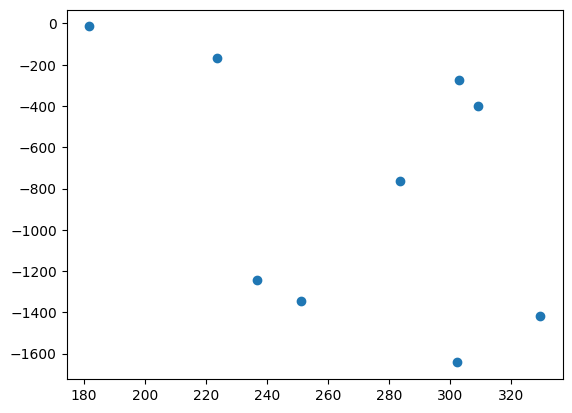

array([0, 1, 2, 2, 2, 1, 1, 2, 2])

In [45]:
sections = [node for node in segs if node.is_section]
x_values = np.array([node.x for node in sections])
print(x_values)
y_values = np.array([node.y for node in sections])
plt.scatter(x=x_values, y=-y_values)
plt.show()
levels = find_clusters(x_values.copy())
levels

Looks like we're using basically the same idea for now. Both datasets have to be sorted for the diffs. But other than that, we use different clustering algorithms because the labels are ordered vs not. Will probably have to look at the efficiency of these and compare, but for now they're decent solutions.

For parsing, will have to figure out class labels and ids, for now its:

large-sections

0. Header
1. Section

by-line

0. None
1. Unordered Bullet
2. Ordered Bullet
3. Text
4. Figure

In [12]:
Entry = namedtuple('Entry', ['node', 'level'])

In [13]:
def is_bullet(node):
    return node.cls_id == 1 or node.cls_id == 2

In [14]:
def is_text(node):
    return node.cls_id == 3

In [15]:
def parse_section(parent, nodes):
    y_values = np.array([node.y for node in nodes])
    vertical_labels = find_pairs(y_values)

    x_values = np.array([node.x for node in nodes])
    text_xs = np.array([[node.x, i] for i, node in enumerate(nodes) if is_text(node)])
    if len(text_xs) == 0:
        return
    horizontal_text_labels = find_clusters(text_xs[:, 0])

    horizontal_labels = np.zeros(len(nodes))
    horizontal_labels[text_xs[:, 1].astype(int)] = horizontal_text_labels

    parents = [Entry(parent, -1)]

    for i in range(len(nodes)):
        if i != len(nodes)-1 and vertical_labels[i] == vertical_labels[i+1]:
            horizontal_labels[i] = max(horizontal_labels[i], horizontal_labels[i+1])
            horizontal_labels[i+1] = max(horizontal_labels[i], horizontal_labels[i+1])

        # Flip bullet and text if text comes first
        if (i != len(nodes)-1 and 
            is_text(nodes[i]) and 
            is_bullet(nodes[i+1]) and
            vertical_labels[i] == vertical_labels[i+1]):

            temp = nodes[i]
            nodes[i] = nodes[i+1]
            nodes[i+1] = temp

        node = nodes[i]
        if is_text(node):
            while (horizontal_labels[i] < parents[-1].level):
                parents.pop()
            node.parent = parents[-1].node
        else:   
            while (horizontal_labels[i] <= parents[-1].level):
                parents.pop()
            node.parent = parents[-1].node

        if is_bullet(node):
            parents.append(Entry(node, horizontal_labels[i]))



In [16]:
extra_node_1 = Node('Text', cls_id=3, x=70, y=325)
extra_node_2 = Node('Text', cls_id=3, x=10, y=375)

[('Text', np.float64(0.0), np.float64(0.0)), ('Text', np.float64(0.0), np.float64(25.919891357421875)), ('Unordered Bullet', np.float64(37.93062400817871), np.float64(79.30574035644531)), ('Text', np.float64(68.0543212890625), np.float64(80.54804611206055)), ('Unordered Bullet', np.float64(34.139055252075195), np.float64(127.39708709716797)), ('Text', np.float64(62.0694580078125), np.float64(132.49720764160156)), ('Unordered Bullet', np.float64(34.23348617553711), np.float64(177.4917221069336)), ('Text', np.float64(66.40689086914062), np.float64(180.02194213867188)), ('Text', np.float64(120.34683227539062), np.float64(227.80298614501953)), ('Unordered Bullet', np.float64(95.29480743408203), np.float64(229.30231475830078)), ('Text', np.float64(300.4113464355469), np.float64(276.0792694091797))]


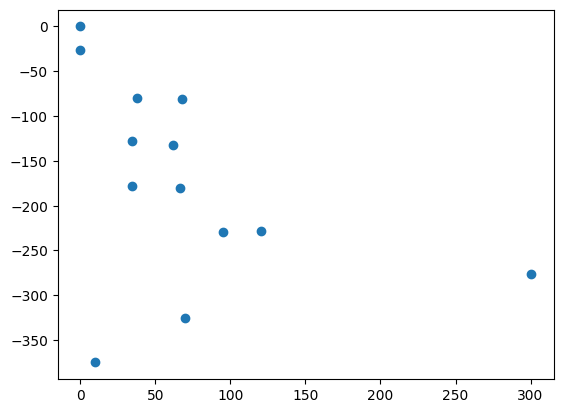

Root
├── Text
├── Text
├── Unordered Bullet
│   └── Text
├── Unordered Bullet
│   └── Text
├── Unordered Bullet
│   ├── Text
│   ├── Unordered Bullet
│   │   ├── Text
│   │   └── Text
│   └── Text
└── Text


In [667]:
test_section = segs[9:20].copy()

print([(node.name, node.x, node.y) for node in test_section])

test_section.append(extra_node_1)
test_section.append(extra_node_2)

x_values = np.array([node.x for node in test_section])
y_values = np.array([node.y for node in test_section])
plt.scatter(x=x_values, y=-y_values)
plt.show()

root = Node("Root", cls_id=-1)
parse_section(root, test_section)

# The Standard Loop
for pre, fill, node in RenderTree(root):
    print(f"{pre}{node.name}")

Looks good! Had to change up some of the logic, resulted in some weird constructions and things that probably have a more efficient way of doing. But for now, it works.

In [17]:
def get_average_angle(nodes):
    sum_r = 0
    for node in nodes:
        sum_r += node.r
    avg_r = sum_r / len(nodes) 
    return avg_r

In [30]:
def correct_node_corners(nodes, center):
    x_values = [node.x for node in nodes]
    y_values = [node.y for node in nodes]

    xy = np.array([x_values, y_values]).T
    angle = get_average_angle(nodes)
    rot = np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle),  np.cos(angle)]
    ])

    return (xy - center) @ rot.T + center

In [19]:
def parse_page(root, nodes, width, height):
    sections = [node for node in nodes if node.is_section]
    indices = [i for i in range(len(nodes)) if nodes[i].is_section] + [len(nodes)]

    xy = correct_node_corners(sections,  (width/2, height/2))
    levels = find_clusters(xy[:, 0])
    
    parents = [Entry(root, -1)]
    for i, (node, level, index) in enumerate(zip(sections, levels, indices)):
        while level <= parents[-1].level:
            parents.pop()
        
        node.parent = parents[-1].node
        parents.append(Entry(node, level))

        parse_section(node, nodes[index+1:indices[i+1]])

This indexing is nasty but eh

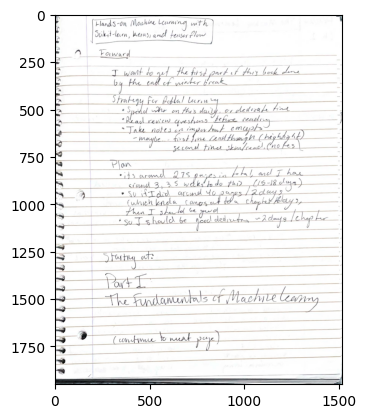

In [655]:
plt.imshow(test_image)

In [671]:
segs = get_page_segmentations(test_image)


0: 1024x800 None54.1ms
Speed: 7.7ms preprocess, 54.1ms inference, 2.9ms postprocess per image at shape (1, 3, 1024, 800)

0: 160x640 2 Texts, 14.9ms
Speed: 1.3ms preprocess, 14.9ms inference, 1.4ms postprocess per image at shape (1, 3, 160, 640)

0: 256x640 1 Text, 16.5ms
Speed: 1.8ms preprocess, 16.5ms inference, 1.4ms postprocess per image at shape (1, 3, 256, 640)

0: 96x640 2 Texts, 12.6ms
Speed: 1.4ms preprocess, 12.6ms inference, 1.4ms postprocess per image at shape (1, 3, 96, 640)

0: 224x640 4 Unordered Bullets, 7 Texts, 12.3ms
Speed: 1.5ms preprocess, 12.3ms inference, 1.3ms postprocess per image at shape (1, 3, 224, 640)

0: 256x640 3 Unordered Bullets, 6 Texts, 12.3ms
Speed: 1.7ms preprocess, 12.3ms inference, 1.2ms postprocess per image at shape (1, 3, 256, 640)

0: 224x640 1 Text, 12.0ms
Speed: 1.8ms preprocess, 12.0ms inference, 1.4ms postprocess per image at shape (1, 3, 224, 640)

0: 320x640 1 Figure, 14.4ms
Speed: 1.8ms preprocess, 14.4ms inference, 1.4ms postprocess 

In [676]:
root = Node("Root", is_section=True)
parse_page(root, segs, test_image.shape[0], test_image.shape[1])

# The Standard Loop
for pre, fill, node in RenderTree(root):
    print(f"{pre}{node.name}")

Root
└── Header
    ├── Text
    ├── Text
    ├── Header
    │   ├── Text
    │   ├── Section
    │   │   ├── Text
    │   │   └── Text
    │   ├── Section
    │   │   ├── Text
    │   │   ├── Text
    │   │   ├── Unordered Bullet
    │   │   │   └── Text
    │   │   ├── Unordered Bullet
    │   │   │   └── Text
    │   │   └── Unordered Bullet
    │   │       ├── Text
    │   │       └── Unordered Bullet
    │   │           ├── Text
    │   │           └── Text
    │   └── Section
    │       ├── Text
    │       ├── Unordered Bullet
    │       │   ├── Text
    │       │   └── Text
    │       ├── Unordered Bullet
    │       │   ├── Text
    │       │   ├── Text
    │       │   └── Text
    │       └── Unordered Bullet
    ├── Header
    │   └── Text
    └── Section
        ├── Section
        │   ├── Text
        │   └── Text
        └── Section
            └── Text


Alright, after a lot of random debugging (that should probably be refactored later) we've got something that looks... possibly good! Let's try plotting it.

Root
└── Header
    ├── Text


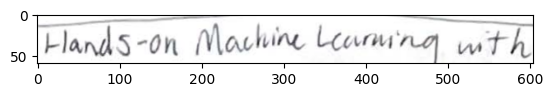

    ├── Text


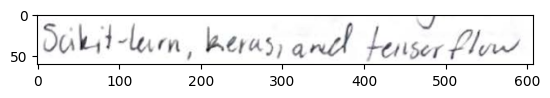

    ├── Header
    │   ├── Text


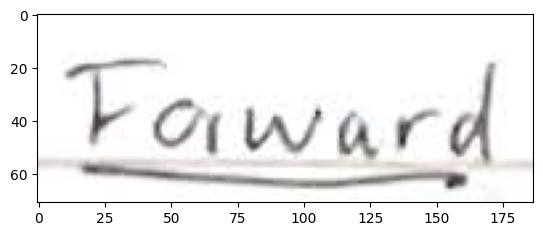

    │   ├── Section
    │   │   ├── Text


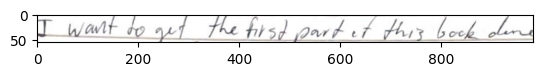

    │   │   └── Text


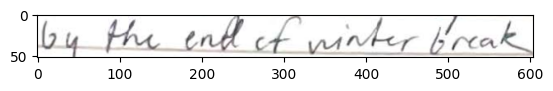

    │   ├── Section
    │   │   ├── Text


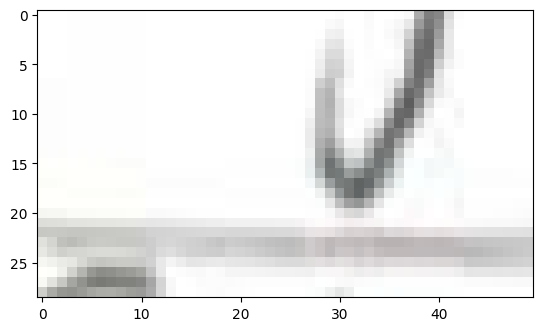

    │   │   ├── Text


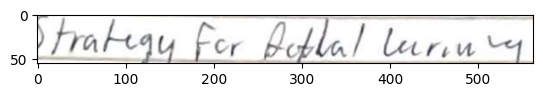

    │   │   ├── Unordered Bullet


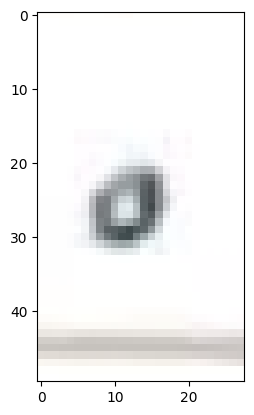

    │   │   │   └── Text


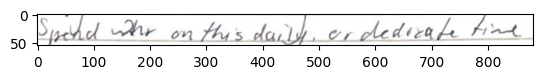

    │   │   ├── Unordered Bullet


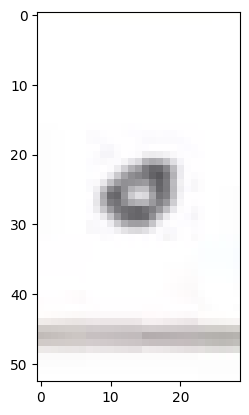

    │   │   │   └── Text


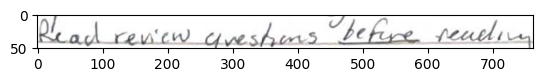

    │   │   └── Unordered Bullet


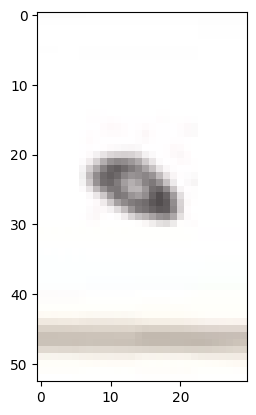

    │   │       ├── Text


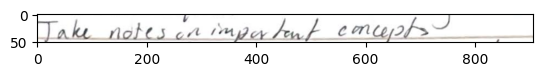

    │   │       └── Unordered Bullet


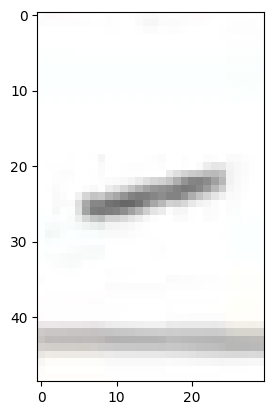

    │   │           ├── Text


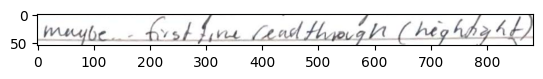

    │   │           └── Text


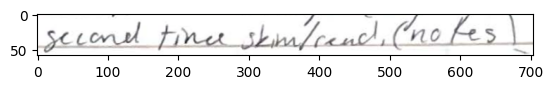

    │   └── Section
    │       ├── Text


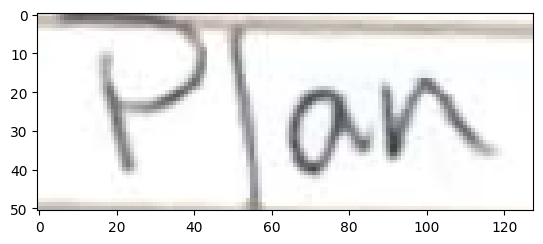

    │       ├── Unordered Bullet


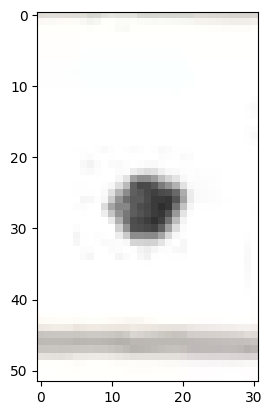

    │       │   ├── Text


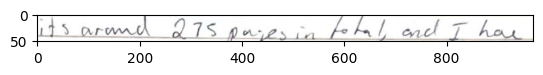

    │       │   └── Text


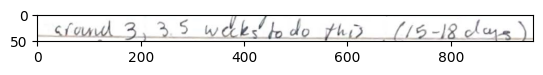

    │       ├── Unordered Bullet


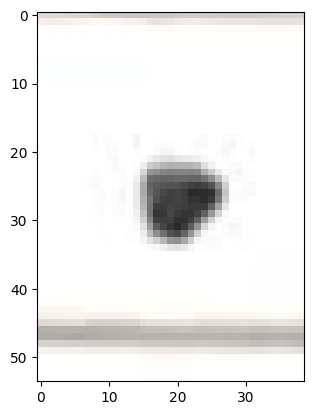

    │       │   ├── Text


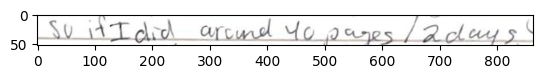

    │       │   ├── Text


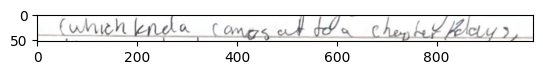

    │       │   └── Text


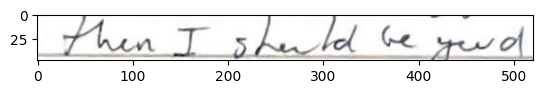

    │       └── Unordered Bullet


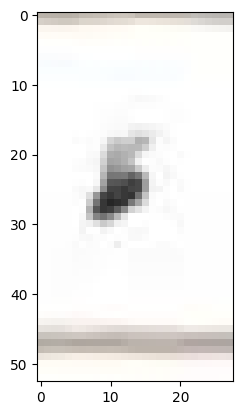

    ├── Header
    │   └── Text


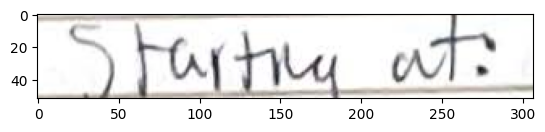

    └── Section
        ├── Section
        │   ├── Text


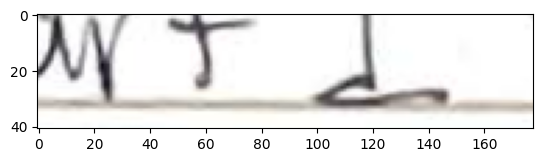

        │   └── Text


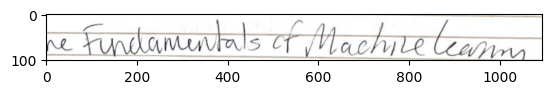

        └── Section
            └── Text


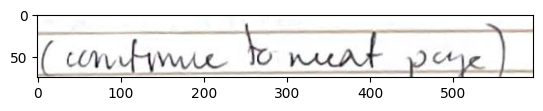

In [677]:
for pre, fill, node in RenderTree(root):
    print(f"{pre}{node.name}")
    if not node.is_section:
        plt.imshow(node.img)
        plt.show()

For a first pass through... looks great! Let's see what it does for another one.

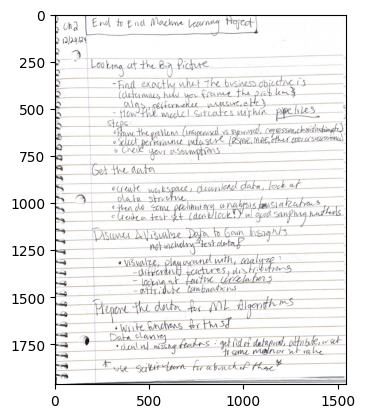

In [38]:
test_image_2_path = r"C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\large-sections\data\images\train\note-transfer ch1-6_Page_05_Image_0001.jpg"
test_image_2 = cv2.imread(test_image_2_path, cv2.IMREAD_ANYCOLOR)
plt.imshow(test_image_2)

In [39]:
segs_2 = get_page_segmentations(test_image_2)


0: 1024x832 None59.6ms
Speed: 9.3ms preprocess, 59.6ms inference, 3.4ms postprocess per image at shape (1, 3, 1024, 832)
Incompatible crop: (0, 886, 3)

0: 160x640 1 Text, 13.8ms
Speed: 1.2ms preprocess, 13.8ms inference, 1.4ms postprocess per image at shape (1, 3, 160, 640)

0: 192x640 3 Unordered Bullets, 6 Texts, 14.2ms
Speed: 1.8ms preprocess, 14.2ms inference, 2.3ms postprocess per image at shape (1, 3, 192, 640)

0: 192x640 1 Text, 14.1ms
Speed: 2.1ms preprocess, 14.1ms inference, 1.7ms postprocess per image at shape (1, 3, 192, 640)

0: 192x640 4 Texts, 13.3ms
Speed: 1.7ms preprocess, 13.3ms inference, 2.4ms postprocess per image at shape (1, 3, 192, 640)

0: 128x640 2 Texts, 13.2ms
Speed: 1.1ms preprocess, 13.2ms inference, 2.3ms postprocess per image at shape (1, 3, 128, 640)

0: 192x640 4 Unordered Bullets, 4 Texts, 13.9ms
Speed: 1.8ms preprocess, 13.9ms inference, 1.8ms postprocess per image at shape (1, 3, 192, 640)

0: 96x640 1 Text, 11.4ms
Speed: 0.8ms preprocess, 11.4ms

Header


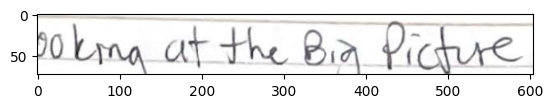

Section


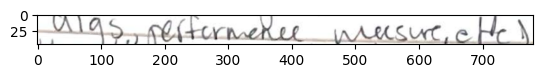

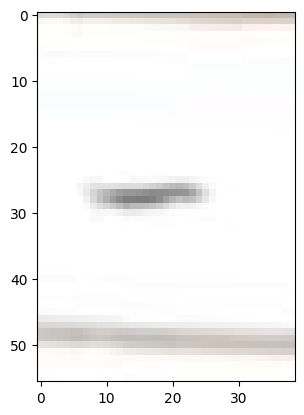

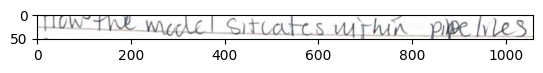

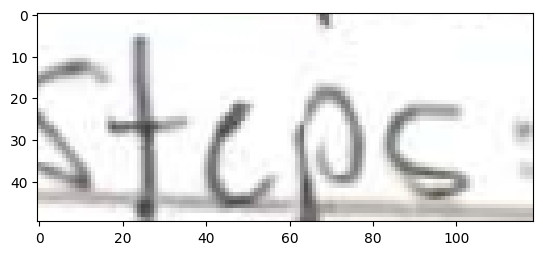

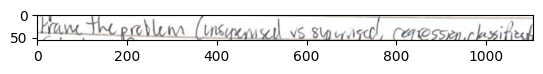

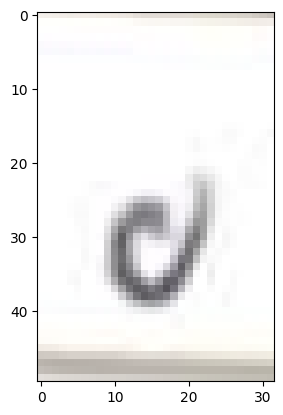

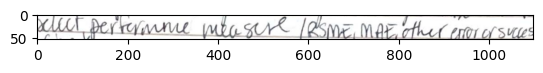

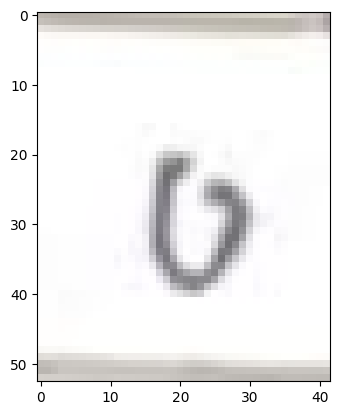

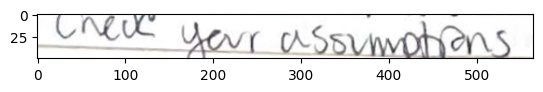

Header


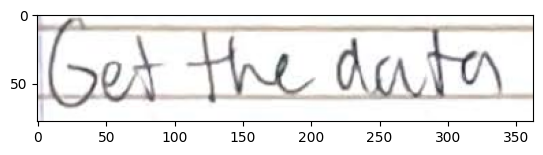

Section


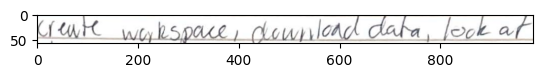

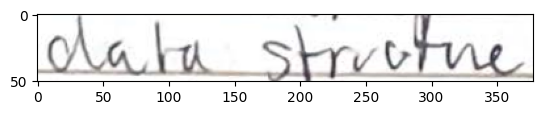

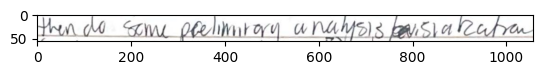

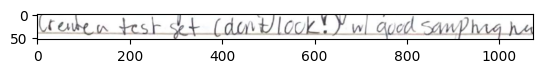

Header


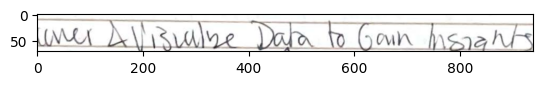

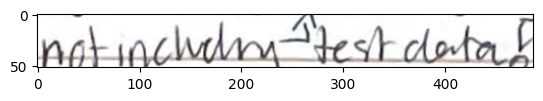

Section


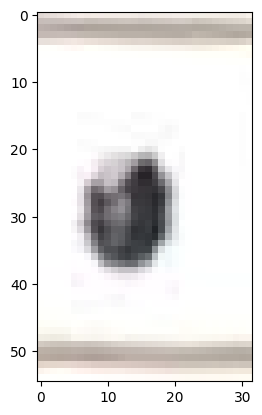

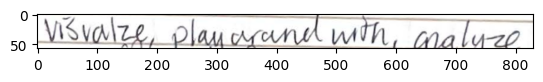

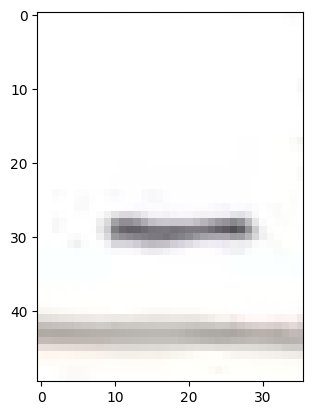

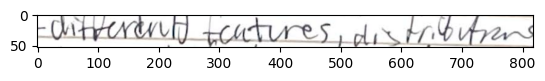

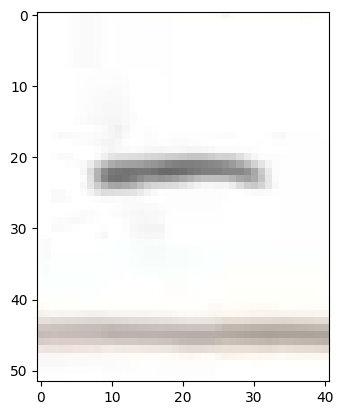

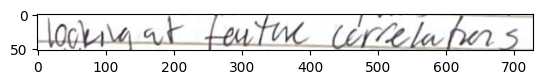

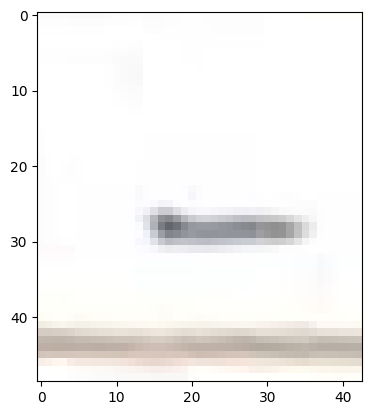

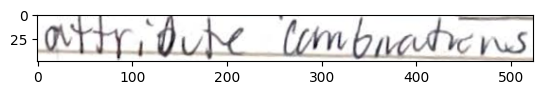

Header


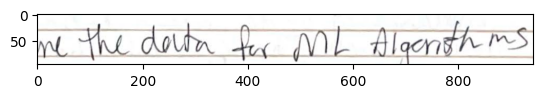

Section


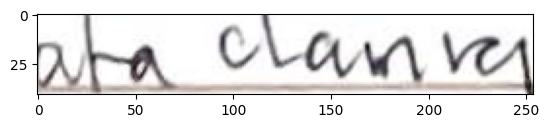

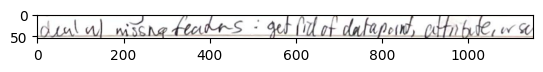

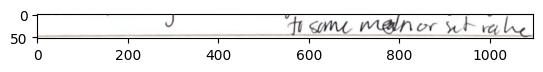

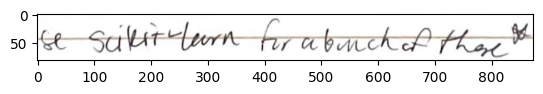

In [40]:
for seg in segs_2:
    if seg.is_section:
        print(seg.name)
    else:
        plt.imshow(seg.img)
        plt.show()

In [41]:
root_2 = Node("Root_2", is_section=True)
parse_page(root_2, segs_2, test_image_2.shape[0], test_image_2.shape[1])

In [42]:
for pre, fill, node in RenderTree(root_2):
    print(f"{pre}{node.name}")

Root_2
└── Header
    ├── Text
    └── Section
        ├── Unordered Bullet
        │   ├── Text
        │   ├── Text
        │   ├── Text
        │   └── Text
        ├── Unordered Bullet
        ├── Unordered Bullet
        │   ├── Text
        │   └── Text
        └── Header
            ├── Text
            ├── Section
            │   ├── Text
            │   ├── Text
            │   ├── Text
            │   ├── Text
            │   └── Header
            │       ├── Text
            │       └── Text
            ├── Section
            │   └── Unordered Bullet
            │       ├── Text
            │       ├── Unordered Bullet
            │       │   └── Text
            │       ├── Unordered Bullet
            │       │   └── Text
            │       └── Unordered Bullet
            │           └── Text
            ├── Header
            │   └── Text
            └── Section
                ├── Text
                ├── Text
                ├── Text
                └── Text


Root_2
└── Header
    ├── Text


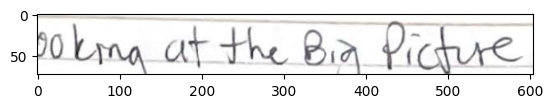

    └── Section
        ├── Unordered Bullet


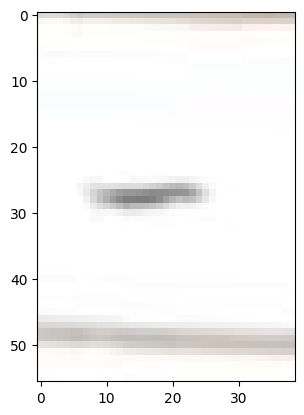

        │   ├── Text


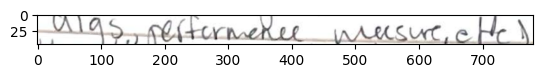

        │   ├── Text


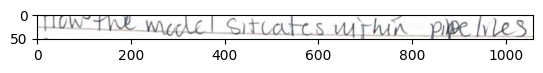

        │   ├── Text


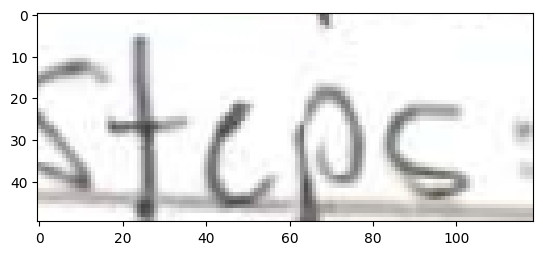

        │   └── Text


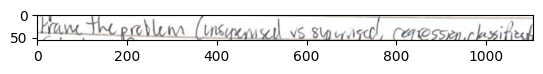

        ├── Unordered Bullet


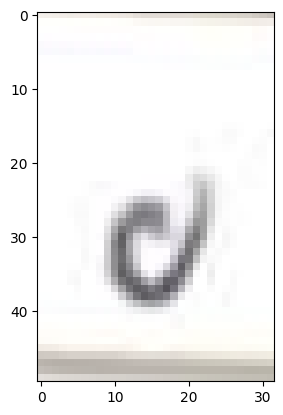

        ├── Unordered Bullet


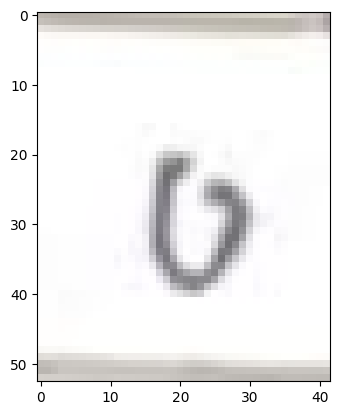

        │   ├── Text


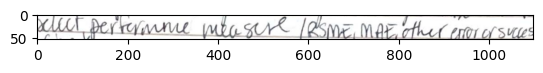

        │   └── Text


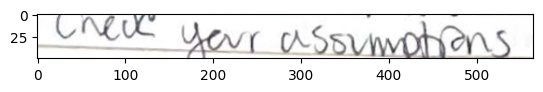

        └── Header
            ├── Text


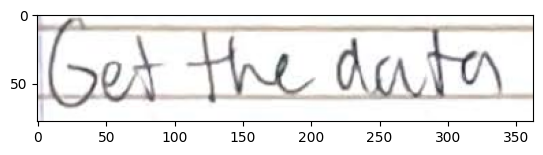

            ├── Section
            │   ├── Text


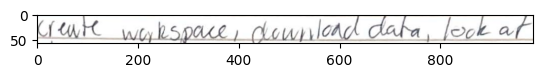

            │   ├── Text


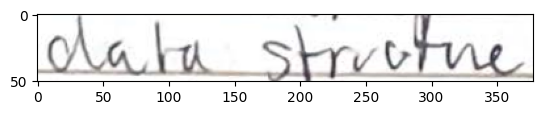

            │   ├── Text


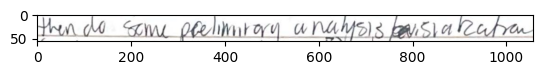

            │   ├── Text


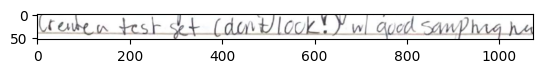

            │   └── Header
            │       ├── Text


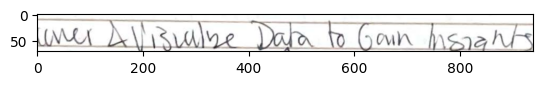

            │       └── Text


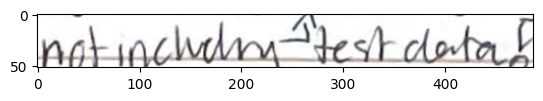

            ├── Section
            │   └── Unordered Bullet


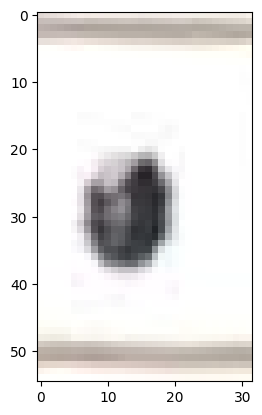

            │       ├── Text


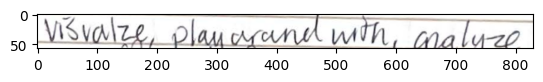

            │       ├── Unordered Bullet


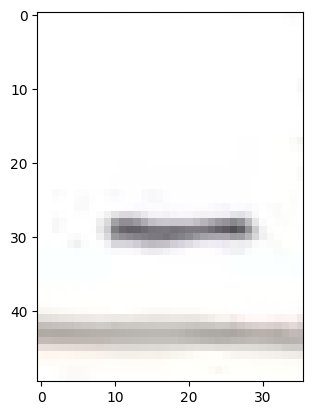

            │       │   └── Text


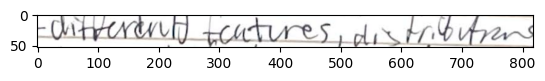

            │       ├── Unordered Bullet


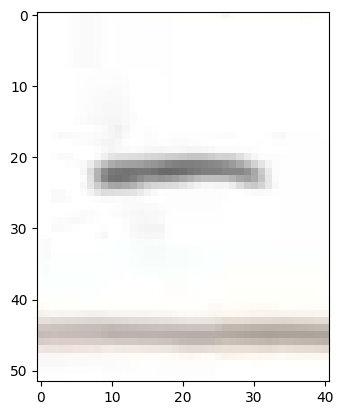

            │       │   └── Text


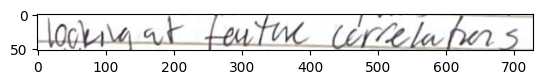

            │       └── Unordered Bullet


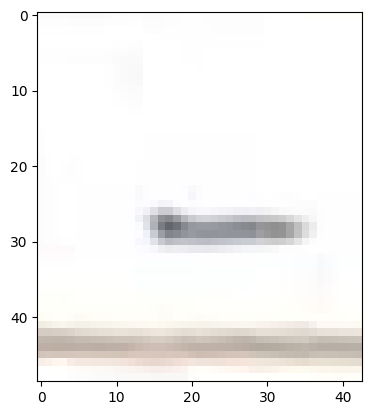

            │           └── Text


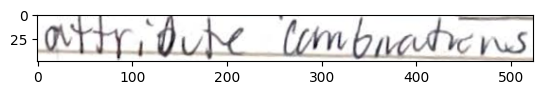

            ├── Header
            │   └── Text


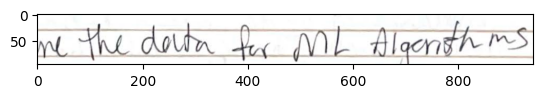

            └── Section
                ├── Text


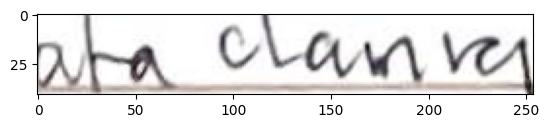

                ├── Text


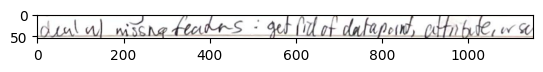

                ├── Text


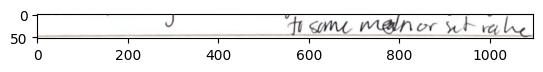

                └── Text


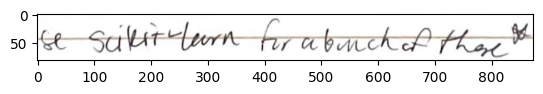

In [43]:
for pre, fill, node in RenderTree(root_2):
    print(f"{pre}{node.name}")
    if not node.is_section:
        plt.imshow(node.img)
        plt.show()

Not so great, probably just need the models better though

#### Some Thoughts

This doesn't take multi-columned approaches into account, neither diagrams/equations/etc. Its assuming a very simple, kind of document-style structure.

We'll work on that more complex parsing later. Right now, we have to get the models better. Neither the sectioning or the line detection are where I want them to be. Need to be more precise with my labelling, and just have more labels.

# Better Models

Our full page segmentation did pretty well, but they require our segmentation models to be more accurate with their segmentation.

So, I'm going to do a few things to try and help remedy that:

- Pre-processing of images to increase contrast, possibly emphasize the text more, minimize light/distracting strokes
- Labelling our current sections and lines better
- Scanning more notes and labelling them, focusing on a smaller scope/simpler structure of notes

## More Precise Segmentation

Starting off, I'll work on labelling our segmentation models with more precision.

The main philosophy is that we want to have the logic for organization embedded in our program, not the model. The model works to detect different sections, so we should be as precise as possible for only that when labelling, not adding different padding just because it looks the best. Our clustering and other parsing algorithms should be the ones handling that portion, and should be able to work with a little bit of noise in the indentation of the notes.

First, let's check what the current performance look like for our large sections:

In [11]:
model_path = Path(r"C:\Users\gjbur\Desktop\Code\note-transfer\development\runs\refining-two-step\large-section\train2\weights\best.pt")
model = YOLO(model_path)

data_path = Path(r"C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\large-sections\data.yaml")

In [12]:
curr_val_results = model.val(data=data_path, agnostic_nms=True).results_dict
curr_val_results

Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
YOLO11n-obb summary (fused): 109 layers, 2,654,113 parameters, 0 gradients, 6.6 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1936.4295.3 MB/s, size: 219.3 KB)


val: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\large-sections\data\labels\train.cache... 3 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3/3 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:02<00:00,  2.34s/it]


                   all          3         21      0.778      0.818      0.881      0.637
                Header          3          7      0.824      0.857      0.913      0.655
               Section          3         14      0.732       0.78      0.849      0.619
Speed: 6.3ms preprocess, 90.8ms inference, 0.0ms loss, 4.3ms postprocess per image
Results saved to c:\Users\gjbur\Desktop\Code\note-transfer\runs\obb\val5


{'metrics/precision(B)': np.float64(0.777671245576776),
 'metrics/recall(B)': np.float64(0.8184718822272579),
 'metrics/mAP50(B)': np.float64(0.8809665685192001),
 'metrics/mAP50-95(B)': np.float64(0.6366103205291582),
 'fitness': np.float64(0.6610459453281624)}

Now, let's train with our new data:

In [22]:
model = YOLO('yolo11n-obb.pt')
yaml_path = Path(r"datasets\refined-two-step\large-sections-12-24\data.yaml")

results = model.train(
    data=yaml_path,
    project='runs/refining-two-step/large-section-12-24',
    epochs=200
)

New https://pypi.org/project/ultralytics/8.3.241 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets\refined-two-step\large-sections-12-24\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=False, 

train: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\large-sections-12-24\data\labels\train... 16 images, 0 backgrounds, 0 corrupt: 100%|██████████| 16/16 [00:00<00:00, 1756.50it/s]

train: New cache created: C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\large-sections-12-24\data\labels\train.cache


val: Fast image access  (ping: 0.50.7 ms, read: 1387.2459.3 MB/s, size: 219.3 KB)


val: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\large-sections-12-24\data\labels\train... 3 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3/3 [00:00<00:00, 3002.37it/s]

...

    200/200      9.27G     0.9177      1.081        2.5        120       1024: 100%|██████████| 1/1 [00:00<00:00,  1.57it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  4.60it/s]

                   all          3         21      0.728      0.761      0.841      0.521



200 epochs completed in 0.159 hours.
Optimizer stripped from runs\refining-two-step\large-section-12-24\train\weights\last.pt, 5.8MB
Optimizer stripped from runs\refining-two-step\large-section-12-24\train\weights\best.pt, 5.8MB

Validating runs\refining-two-step\large-section-12-24\train\weights\best.pt...
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
YOLO11n-obb summary (fused): 109 layers, 2,654,113 parameters, 0 gradients, 6.6 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  6.74it/s]


                   all          3         21      0.766       0.76      0.856      0.545
                Header          3          7      0.777      0.857      0.885      0.565
               Section          3         14      0.755      0.662      0.827      0.526
Speed: 0.8ms preprocess, 34.2ms inference, 0.0ms loss, 4.8ms postprocess per image
Results saved to runs\refining-two-step\large-section-12-24\train


In [23]:
results.results_dict

{'metrics/precision(B)': np.float64(0.7661495002799699),
 'metrics/recall(B)': np.float64(0.7597394070166348),
 'metrics/mAP50(B)': np.float64(0.8559558080808081),
 'metrics/mAP50-95(B)': np.float64(0.5453797482202631),
 'fitness': np.float64(0.5764373542063176)}

In [28]:
new_val_results = model.val(
    data=yaml_path,
    project='runs/refining-two-step/large-section-12-24/',
    name='val',
    agnostic_nms=True
)
new_val_results.results_dict

Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 1750.6384.6 MB/s, size: 219.3 KB)


val: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\large-sections-12-24\data\labels\train.cache... 3 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3/3 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:02<00:00,  2.81s/it]


                   all          3         21      0.755       0.76      0.829      0.529
                Header          3          7      0.754      0.857      0.885      0.557
               Section          3         14      0.756      0.663      0.772      0.501
Speed: 6.6ms preprocess, 346.2ms inference, 0.0ms loss, 3.6ms postprocess per image
Results saved to runs\refining-two-step\large-section-12-24\val


{'metrics/precision(B)': np.float64(0.7545159906233763),
 'metrics/recall(B)': np.float64(0.7602669126035486),
 'metrics/mAP50(B)': np.float64(0.8285342771607477),
 'metrics/mAP50-95(B)': np.float64(0.528996427302545),
 'fitness': np.float64(0.5589502122883653)}

A little worse, actually. Just seeing a lot of header mislabeling.

Note that we only have 18 training images for this, which is an extrememly small sample size. So, I'm confident that with more data, this will be much more effective

Onto the by-line retraining...

In [29]:
model_path = Path(r"C:\Users\gjbur\Desktop\Code\note-transfer\development\runs\refining-two-step\by-line\train\weights\best.pt")
model = YOLO(model_path)

data_path = Path(r"C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\by-line\data.yaml")

In [30]:
curr_val_results = model.val(data=data_path, agnostic_nms=True).results_dict
curr_val_results

Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
YOLO11n summary (fused): 100 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.40.2 ms, read: 139.9105.3 MB/s, size: 55.3 KB)


val: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\by-line\data\labels\train.cache... 21 images, 0 backgrounds, 0 corrupt: 100%|██████████| 21/21 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:03<00:00,  1.61s/it]


                   all         21         81      0.892      0.937      0.939      0.577
      Unordered Bullet         10         20      0.984       0.95      0.983      0.423
                  Text         18         58      0.943      0.862       0.92      0.661
                Figure          3          3       0.75      0.998      0.913      0.646
Speed: 2.9ms preprocess, 53.7ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to c:\Users\gjbur\Desktop\Code\note-transfer\runs\detect\val


{'metrics/precision(B)': np.float64(0.8923882888849105),
 'metrics/recall(B)': np.float64(0.9366356692721611),
 'metrics/mAP50(B)': np.float64(0.9385902398624002),
 'metrics/mAP50-95(B)': np.float64(0.5767540936082981),
 'fitness': np.float64(0.6129377082337083)}

With new data:

In [2]:
model = YOLO('yolo11n.pt')
yaml_path = Path(r"datasets\refined-two-step\by-line-12-19\data.yaml")

results = model.train(
    data=yaml_path,
    project='runs/refining-two-step/by-line-12-19',
    epochs=200
)

New https://pypi.org/project/ultralytics/8.3.241 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets\refined-two-step\by-line-12-19\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2,

train: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\by-line-12-19\data\labels\train... 133 images, 0 backgrounds, 0 corrupt: 100%|██████████| 133/133 [00:00<00:00, 3207.12it/s]

train: New cache created: C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\by-line-12-19\data\labels\train.cache


val: Fast image access  (ping: 0.40.3 ms, read: 220.5185.1 MB/s, size: 46.5 KB)


val: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\by-line-12-19\data\labels\train... 21 images, 0 backgrounds, 0 corrupt: 100%|██████████| 21/21 [00:00<00:00, 1195.80it/s]

...

    200/200      2.71G     0.7404     0.5415     0.9566         16        640: 100%|██████████| 9/9 [00:01<00:00,  5.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 11.98it/s]

                   all         21         81      0.928      0.924      0.957      0.628



200 epochs completed in 0.142 hours.
Optimizer stripped from runs\refining-two-step\by-line-12-19\train2\weights\last.pt, 5.5MB
Optimizer stripped from runs\refining-two-step\by-line-12-19\train2\weights\best.pt, 5.5MB

Validating runs\refining-two-step\by-line-12-19\train2\weights\best.pt...
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
YOLO11n summary (fused): 100 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 10.93it/s]


                   all         21         81      0.927      0.913      0.956       0.66
      Unordered Bullet         10         20      0.946      0.869      0.932      0.447
                  Text         18         58      0.962      0.869       0.94      0.671
                Figure          3          3      0.875          1      0.995      0.863
Speed: 0.1ms preprocess, 0.8ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs\refining-two-step\by-line-12-19\train2


In [3]:
results.results_dict

{'metrics/precision(B)': np.float64(0.927466486633414),
 'metrics/recall(B)': np.float64(0.912533194902878),
 'metrics/mAP50(B)': np.float64(0.9557692909109982),
 'metrics/mAP50-95(B)': np.float64(0.6602312428878979),
 'fitness': np.float64(0.689785047690208)}

In [6]:
new_val_results = model.val(
    data=yaml_path,
    project='runs/refining-two-step/by-line-12-19',
    agnostic_nms=True,
    iou=0.5,
    name='val'
)
new_val_results.results_dict

Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
val: Fast image access  (ping: 0.10.1 ms, read: 362.6274.2 MB/s, size: 46.1 KB)


val: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\by-line-12-19\data\labels\train.cache... 21 images, 0 backgrounds, 0 corrupt: 100%|██████████| 21/21 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:02<00:00,  1.30s/it]


                   all         21         81      0.942        0.9       0.94      0.644
      Unordered Bullet         10         20      0.915       0.85      0.916      0.422
                  Text         18         58      0.943      0.851       0.91       0.68
                Figure          3          3      0.969          1      0.995       0.83
Speed: 0.8ms preprocess, 14.4ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs\refining-two-step\by-line-12-19\val2


{'metrics/precision(B)': np.float64(0.9420945717980339),
 'metrics/recall(B)': np.float64(0.9002243129420794),
 'metrics/mAP50(B)': np.float64(0.9404079969339789),
 'metrics/mAP50-95(B)': np.float64(0.6440209508751688),
 'fitness': np.float64(0.6736596554810499)}

Okay, this one looks a little better with precision, maybe a little worse recall. Overall it's pretty good, especially because of the imbalances with the classes.

## Adding Data

Our dataset is relatively small right now, so I'm going to retrain with a larger dataset

Right now, I think the main issue is the sectioning data. I'll have to scan more pages in and get those labelled.

### Larger Sections

Have to do some quick conversions of labels because the saved class is different than in training.

In [30]:
label_folder = Path(r"datasets\refined-two-step\large-sections-12-31\labels")

In [20]:
for label_name in os.listdir(label_folder):
    label_path = os.path.join(label_folder, label_name)

    with open(label_path, "r") as f:
        lines = []
        for line in f:
            if line[0] == "4":
                line = "1" + line[1:]
            lines.append(line)

    with open(label_path, "w") as f:
        f.writelines(lines)

Here's some helpers for splitting train/val/test:

In [6]:
def save_labels_to_file(file_path, labels):
    with open(file_path, 'w+') as f:
        for label in labels:
            f.write(f'{label}\n')

In [52]:
def split_labels(main_folder, label_folders, image_maxes, train_split=(0.8, 0.1, 0.1), seed=42):
    train_ratio, val_ratio, test_ratio = train_split
    train_labels, val_labels, test_labels = [], [], []

    for label_folder, image_max in zip(label_folders, image_maxes):
        labels = os.listdir(label_folder)

        # Shuffle and split labels
        random.seed(seed)
        random.shuffle(labels)

        labels = labels[:image_max]
        first, second = int(train_ratio*len(labels)), int((train_ratio+val_ratio)*len(labels))

        train = labels[:first] 
        val = labels[first:second]
        test = labels[second:]

        # Add their respective paths
        for label in train:
            label = label[:-3] + 'jpg'
            train_labels.append('./images/' + label)
        for label in val:
            label = label[:-3] + 'jpg'
            val_labels.append('./images/' + label)
        for label in test:
            label = label[:-3] + 'jpg'
            test_labels.append('./images/' + label)

    # Save each to file
    save_labels_to_file(os.path.join(main_folder, 'train_split.txt'), train_labels)
    save_labels_to_file(os.path.join(main_folder, 'val_split.txt'), val_labels)
    save_labels_to_file(os.path.join(main_folder, 'test_split.txt'), test_labels)

In [53]:
main_folder = Path(r"datasets\refined-two-step\large-sections-12-31")
label_folders = [
    Path(r"datasets\refined-two-step\large-sections-12-31\labels"),
]

In [54]:
split_labels(main_folder, label_folders, [1000]*len(label_folders), train_split=(0.7, 0.15, 0.15))

This new dataset for the large sections has 73 images, we use a 70/15/15 split to get 51 train, 11 validation, and 11 test images.

Let's see how to current model does on the testing and validation images:

In [31]:
model_path = Path(r"runs\refining-two-step\large-section-12-24\train\weights\best.pt")
model = YOLO(model_path)

In [56]:
yaml_path = Path(r"datasets\refined-two-step\large-sections-12-31\data.yaml")

results = model.val(
    data=yaml_path,
    project='runs/refining-two-step/large-section-12-31',
    name='eval_12_24_model',
    iou=0.5
)

Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
val: Fast image access  (ping: 0.10.1 ms, read: 2003.4440.0 MB/s, size: 224.7 KB)


val: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\large-sections-12-31\labels.cache... 11 images, 0 backgrounds, 0 corrupt: 100%|██████████| 11/11 [00:00<?, ?it/s]


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:03<00:00,  3.73s/it]


                   all         11        100      0.854      0.867      0.922      0.672
                Header         11         28      0.777      0.997      0.952      0.712
               Section         11         72       0.93      0.737      0.892      0.631
Speed: 10.4ms preprocess, 31.0ms inference, 0.0ms loss, 20.8ms postprocess per image
Results saved to runs\refining-two-step\large-section-12-31\eval_12_24_model


In [57]:
results.results_dict

{'metrics/precision(B)': np.float64(0.8535875597781767),
 'metrics/recall(B)': np.float64(0.8670877825201302),
 'metrics/mAP50(B)': np.float64(0.9222061209934569),
 'metrics/mAP50-95(B)': np.float64(0.6718381608196812),
 'fitness': np.float64(0.6968749568370588)}

Similar performance as before... now let's train on the new dataset.

In [2]:
model = YOLO('yolo11n-obb.pt')

In [4]:
yaml_path = Path(r"datasets\refined-two-step\large-sections-12-31\data.yaml")
results = model.train(
    data=yaml_path,
    project='runs/refining-two-step/large-section-12-31',
    name='first_train',
    epochs=200
)

Ultralytics 8.3.249  Python-3.12.3 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets\refined-two-step\large-sections-12-31\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=first_train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl

In [5]:
results.results_dict

{'metrics/precision(B)': 0.9153668696762032,
 'metrics/recall(B)': 0.9517077868141698,
 'metrics/mAP50(B)': 0.975727894207523,
 'metrics/mAP50-95(B)': 0.8354300500194493,
 'fitness': 0.8354300500194493}

Much better!

In [11]:
results = model.val(
    data=yaml_path,
    split='test',
    project='runs/refining-two-step/large-section-12-31',
    name='first_test',
    iou=0.5
)

Ultralytics 8.3.249  Python-3.12.3 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
val: Fast image access  (ping: 0.20.0 ms, read: 1452.0437.1 MB/s, size: 215.0 KB)
val: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\large-sections-12-31\labels.cache... 11 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 11/11 11.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.7s/it 2.7s
                   all         11        100      0.927      0.952      0.977      0.836
                Header         11         28      0.927      0.903      0.974      0.828
               Section         11         72      0.926          1       0.98      0.843
Speed: 7.4ms preprocess, 39.3ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to C:\Users\gjbur\Desktop\Code\note-transfer\development\runs\refining-two-step\large-section-12-31\first_test


In [12]:
results.results_dict

{'metrics/precision(B)': 0.9265117615299123,
 'metrics/recall(B)': 0.9516222352339501,
 'metrics/mAP50(B)': 0.9773210476756864,
 'metrics/mAP50-95(B)': 0.835734889514176,
 'fitness': 0.835734889514176}

In [13]:
results = model.val(
    data=yaml_path,
    split='val',
    project='runs/refining-two-step/large-section-12-31',
    name='first_val',
    iou=0.5
)

Ultralytics 8.3.249  Python-3.12.3 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 2066.3265.9 MB/s, size: 216.7 KB)
val: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\large-sections-12-31\labels.cache... 11 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 11/11  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.5s/it 2.5s
                   all         11        100      0.927      0.952      0.977      0.836
                Header         11         28      0.927      0.903      0.974      0.828
               Section         11         72      0.926          1       0.98      0.843
Speed: 4.1ms preprocess, 22.6ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to C:\Users\gjbur\Desktop\Code\note-transfer\development\runs\refining-two-step\large-section-12-31\first_val


In [14]:
results.results_dict

{'metrics/precision(B)': 0.9265117615299123,
 'metrics/recall(B)': 0.9516222352339501,
 'metrics/mAP50(B)': 0.9773210476756864,
 'metrics/mAP50-95(B)': 0.835734889514176,
 'fitness': 0.835734889514176}

Holds up in testing as well!

THis is good to see, getting decent performance even with only 51 training images.